In [1]:
# import data
import os
from datasets import load_dataset

# basic
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import re
from tqdm import tqdm

# pre-processing
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV, cross_val_predict, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# model
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error, mean_pinball_loss
from itertools import combinations
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

import shap


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# PART 1. Data Pre-processing

#### 1. Load data

In [2]:
# load data from Hugging face
ds = load_dataset("aneesarom/Food-Delivery")

# convert to dataframe
df = pd.concat([ds['train'].to_pandas(), ds['test'].to_pandas()], ignore_index=True)

# sanity check
print(df.shape)
df.head()

(45584, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0x6bbb,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17
1,0x190a,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33
2,0x120c,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20
3,0x6016,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27
4,0x9ca0,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26


#### 2. Format Conversion

In [3]:
# 1. check all columns info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_condition          

In [4]:
# 2. Convert date format
# Convert Order_Date (format: DD-MM-YYYY) to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')

# Check how many failed to convert (became NaT)
print(f"Order_Date NaT count: {df['Order_Date'].isnull().sum()}")

Order_Date NaT count: 0


In [5]:
# 3. Convert time format
# Check if any time format is out of pattern HH:MM
pattern = re.compile(r'^\d{2}:\d{2}$')

def check_suspicious_times(df, column):
    value_counts = df[column].value_counts(dropna=False)
    suspicious_counts = value_counts[~value_counts.index.astype(str).str.match(pattern)]
    print(f"--- {column} ---")
    print(suspicious_counts)
    print(f"Total suspicious rows: {suspicious_counts.sum()}\n")
    return suspicious_counts

check_suspicious_times(df, 'Time_Orderd')
check_suspicious_times(df, 'Time_Order_picked')

--- Time_Orderd ---
Time_Orderd
NaN            1731
0.833333333     449
1               430
0.791666667     424
0.958333333     422
0.875           409
0.916666667     404
0.75            402
0.416666667     211
0.458333333     193
0.5             189
0.375           177
0.625            86
0.541666667      79
0.583333333      74
0.708333333      66
0.666666667      53
Name: count, dtype: int64
Total suspicious rows: 5799

--- Time_Order_picked ---
Time_Order_picked
0.833333333    452
1              440
24:05:00       435
0.916666667    430
0.75           422
0.875          416
0.958333333    411
0.791666667    403
24:10:00       280
0.375          201
0.416666667    194
0.5            188
24:15:00       165
0.458333333    148
0.625          100
0.666666667     91
0.541666667     83
0.583333333     82
0.708333333     66
Name: count, dtype: int64
Total suspicious rows: 5007



Time_Order_picked
0.833333333    452
1              440
24:05:00       435
0.916666667    430
0.75           422
0.875          416
0.958333333    411
0.791666667    403
24:10:00       280
0.375          201
0.416666667    194
0.5            188
24:15:00       165
0.458333333    148
0.625          100
0.666666667     91
0.541666667     83
0.583333333     82
0.708333333     66
Name: count, dtype: int64

In [6]:
# function to parse time 
def parse_time_value(val):
    if pd.isnull(val):
        return pd.NaT
    
    if isinstance(val, str):
        val = val.strip()
        if val.lower() == 'nan' or val == '':
            return pd.NaT
    
    # Try parsing as Excel-style fraction of a day (numeric), valid range [0, 1]
    try:
        frac = float(val)
        if 0 <= frac <= 1:
            total_seconds = round(frac * 24 * 3600)
            rollover_days = total_seconds // (24 * 3600)  # 1 if frac == 1.0, else 0
            hours = (total_seconds // 3600) % 24
            minutes = (total_seconds % 3600) // 60
            base = pd.to_datetime(f"{hours:02d}:{minutes:02d}", format='%H:%M', errors='coerce')
            return base + pd.Timedelta(days=rollover_days)
        else:
            return pd.NaT
    except (ValueError, TypeError):
        pass
    
    # Try HH:MM:SS strings with hour possibly = 24 (roll over to next day, 00:xx)
    match = re.match(r'^(\d{2}):(\d{2}):(\d{2})$', val)
    if match:
        h, m, s = int(match.group(1)), int(match.group(2)), int(match.group(3))
        rollover_days = h // 24  # 1 if h == 24, else 0
        h = h % 24
        base = pd.to_datetime(f"{h:02d}:{m:02d}", format='%H:%M', errors='coerce')
        return base + pd.Timedelta(days=rollover_days)
    
    # Otherwise, try parsing as a normal HH:MM string
    return pd.to_datetime(val, format='%H:%M', errors='coerce')

df['Time_Ordered'] = df['Time_Orderd'].apply(parse_time_value)
df['Time_Order_Picked'] = df['Time_Order_picked'].apply(parse_time_value)

print(f"Time_Ordered NaT count: {df['Time_Ordered'].isnull().sum()}")
print(f"Time_Order_Picked NaT count: {df['Time_Order_Picked'].isnull().sum()}")

Time_Ordered NaT count: 1731
Time_Order_Picked NaT count: 0


#### 3. Missing values

In [7]:
# 1. Check overall NA counts first
# Replace any NaN string to NA
df = df.replace('NaN', np.nan)

# Check missing value counts
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
Time_Ordered                   1731
Time_Order_Picked                 0
dtype: int64

In [8]:
# 2. check values of string columns
# cols = ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
# for x in cols:
#     print(f"--- {x} ---")
#     print(df[x].value_counts(dropna=False).to_string())
#     print()

# print(df['Weather_conditions'].value_counts(dropna=False).to_string())
# print(df['Road_traffic_density'].value_counts(dropna=False).to_string())
# print(df['Type_of_order'].value_counts(dropna=False).to_string())
# print(df['Type_of_vehicle'].value_counts(dropna=False).to_string())
# print(df['Festival'].value_counts(dropna=False).to_string())
# print(df['City'].value_counts(dropna=False).to_string())

In [8]:
# 3. Remove missing values
# Remove missing values
df_clean = df.dropna()

# sanity check
print(f"Original shape: {df.shape}")
print(f"After dropping missing values: {df_clean.shape}")

# print all columns info
df_clean.info()

Original shape: (45584, 22)
After dropping missing values: (41359, 22)
<class 'pandas.DataFrame'>
Index: 41359 entries, 0 to 45583
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           41359 non-null  str           
 1   Delivery_person_ID           41359 non-null  str           
 2   Delivery_person_Age          41359 non-null  float64       
 3   Delivery_person_Ratings      41359 non-null  float64       
 4   Restaurant_latitude          41359 non-null  float64       
 5   Restaurant_longitude         41359 non-null  float64       
 6   Delivery_location_latitude   41359 non-null  float64       
 7   Delivery_location_longitude  41359 non-null  float64       
 8   Order_Date                   41359 non-null  datetime64[us]
 9   Time_Orderd                  41359 non-null  str           
 10  Time_Order_picked            41359 non-null  str   

In [9]:
# Check duplicates
print(f"Number of duplicate rows: {df_clean.duplicated().sum()}")

Number of duplicate rows: 0


#### 4. Feature Engineering

In [10]:
# 1. Calculate distance
# Function to calculate Haversine distance
def haversine_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # km

# Distance in km
df_clean['Distance_km'] = haversine_np(df_clean['Restaurant_latitude'],
                                         df_clean['Restaurant_longitude'],
                                         df_clean['Delivery_location_latitude'],
                                         df_clean['Delivery_location_longitude'])

# sanity check
df_clean['Distance_km'].describe()

count    41359.000000
mean        26.915498
std        298.814439
min          1.465067
25%          4.663601
50%          9.268782
75%         13.735954
max       6884.726399
Name: Distance_km, dtype: float64

In [11]:
# 2. Calculate preparation in minutes
# calculate prep time
df_clean['Prep_time_min'] = (
    df_clean['Time_Order_Picked'] - df_clean['Time_Ordered']
    ).dt.total_seconds() / 60

# sanity check
df_clean['Prep_time_min'].describe()

count    41359.000000
mean         9.988999
std          4.086094
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Prep_time_min, dtype: float64

In [12]:
# 3. Order hour
# Extract order hour from Time_Ordered
df_clean['Order_hour'] = df_clean['Time_Ordered'].dt.hour

#### 5. Data Split

In [13]:
# target
y = df_clean['Time_taken (min)']

# X
X = df_clean.drop(columns=['ID',
                            'Delivery_person_ID',
                            'Order_Date',
                            'Time_Orderd',
                            'Time_Order_picked',
                            'Restaurant_latitude',
                            'Restaurant_longitude',
                            'Delivery_location_latitude',
                            'Delivery_location_longitude',
                            'Time_taken (min)',
                            'Time_Ordered',
                            'Time_Order_Picked'])

# sanity check
print('Target:', y.shape)
print('No of features:', X.shape)

Target: (41359,)
No of features: (41359, 13)


In [14]:
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 33087
Test size: 8272


#### 6. Data Patterns

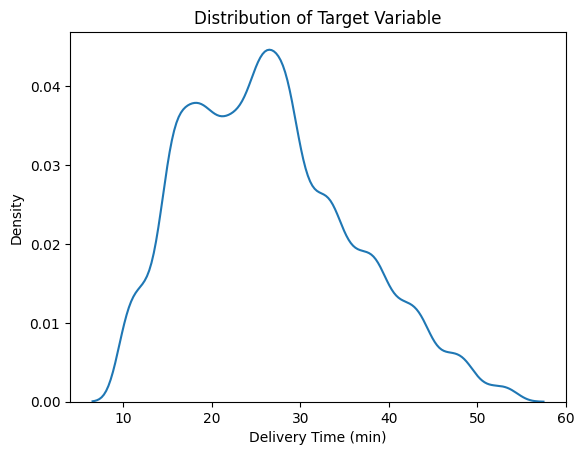

In [15]:
# 1. Distribution of target variable
sns.kdeplot(y_train)
plt.xlabel('Delivery Time (min)')
plt.title('Distribution of Target Variable')
plt.show()

In [16]:
# features
feature_labels = X_train.columns
cat_cols = ['Weather_conditions', 'Road_traffic_density', 'Vehicle_condition',
            'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 
            'Festival', 'City']
num_cols = [x for x in feature_labels if x not in cat_cols]

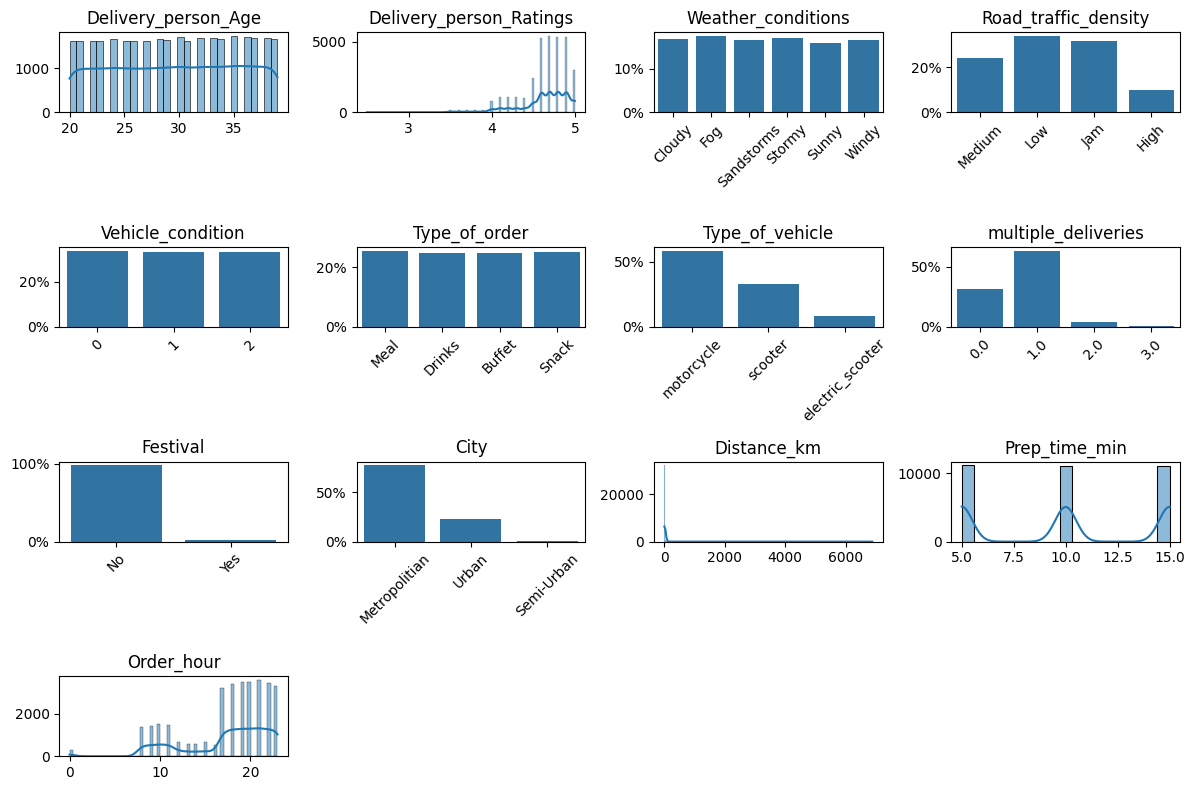

In [18]:
# 2. Distribution of feature variables
ncols = 4
nrows = int(np.ceil(len(feature_labels) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8))
axes = axes.flatten()

# histogram: numerical + count plots: categorical
for i, col in enumerate(feature_labels):
  if col in cat_cols:
    sns.countplot(x=col, data=X_train, ax=axes[i], stat='percent')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].yaxis.set_major_formatter(PercentFormatter(decimals=0))
  else:
    sns.histplot(X_train[col], ax=axes[i], kde=True)

  axes[i].set_title(col)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

# remove unused subplots
for j in range(len(feature_labels), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

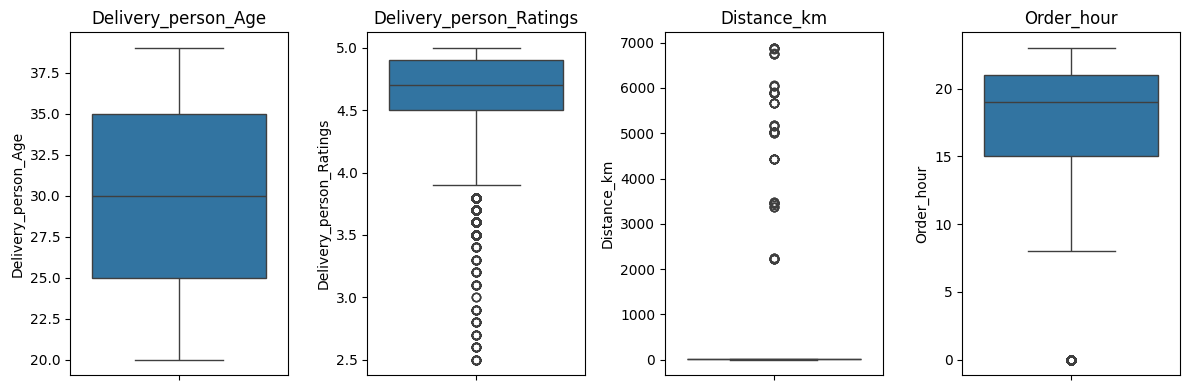

In [24]:
# Box plots of numerical
cols = [x for x in num_cols if x != 'Prep_time_min']
fig, axes = plt.subplots(1, len(cols), figsize=(12,4))
for k, col in enumerate(cols):
    sns.boxplot(y=X_train[col], ax=axes[k])
    axes[k].set_title(col)

plt.tight_layout()
plt.show()

#### 7. Outliers

In [25]:
# Review Distance_km
print("Basic statistics of Distance_km:")
print(X_train['Distance_km'].describe())

# Calculate mean +/- 3 std
mean = X_train['Distance_km'].mean()
std = X_train['Distance_km'].std()
print("\n\nMean +/- 3 std of Distance_km:")
print(mean - 3 * std, mean + 3 * std)

# count for outliers
print("Number of outliers (> mean+3std):", (X_train['Distance_km'] >= mean + 3 * std).sum())
print("Account for:",((X_train['Distance_km'] >= mean + 3 * std).sum() / len(X_train['Distance_km']))*100)


# IQR
Q1 = X_train['Distance_km'].quantile(0.25)
Q3 = X_train['Distance_km'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\n\nLower bound and Upper bound:")
print(lower_bound, upper_bound)

# count number of Distance_km more than upper_bound
print("Number of outliers (> upper_bound):", (X_train['Distance_km'] >= upper_bound).sum())
print("Account for:",((X_train['Distance_km'] >= upper_bound).sum() / len(X_train['Distance_km']))*100)

Basic statistics of Distance_km:
count    33087.000000
mean        26.896662
std        300.023128
min          1.465067
25%          4.663456
50%          9.220835
75%         13.682379
max       6884.726399
Name: Distance_km, dtype: float64


Mean +/- 3 std of Distance_km:
-873.1727229723627 926.9660478063591
Number of outliers (> mean+3std): 116
Account for: 0.3505908665034606


Lower bound and Upper bound:
-8.864927740322289 27.21076284656931
Number of outliers (> upper_bound): 116
Account for: 0.3505908665034606


In [26]:
# filter out outliers
idx_train = (X_train['Distance_km'] >= lower_bound) & (X_train['Distance_km'] <= upper_bound)

# training
X_train_clean = X_train[idx_train]
y_train_clean = y_train[idx_train]

print(f"Removed {(~idx_train).sum()} outlier rows out of {len(X_train)} training rows")
print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"y_train_clean shape: {y_train_clean.shape}")

# test
idx_test = (X_test['Distance_km'] >= lower_bound) & (X_test['Distance_km'] <= upper_bound)
X_test_clean = X_test[idx_test]
y_test_clean = y_test[idx_test]

print(f"Removed {(~idx_test).sum()} outlier rows out of {len(X_test)} testing rows")
print(f"X_test_clean shape: {X_test_clean.shape}")
print(f"y_test_clean shape: {y_test_clean.shape}")


Removed 116 outlier rows out of 33087 training rows
X_train_clean shape: (32971, 13)
y_train_clean shape: (32971,)
Removed 30 outlier rows out of 8272 testing rows
X_test_clean shape: (8242, 13)
y_test_clean shape: (8242,)


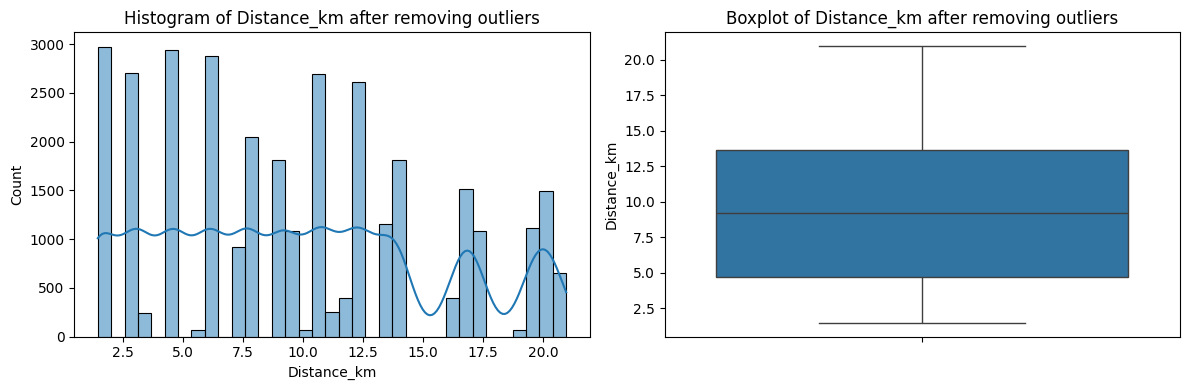

In [27]:
# Visual check: distribution
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(X_train_clean['Distance_km'], kde=True, ax=axes[0])
axes[0].set_title('Histogram of Distance_km after removing outliers')

sns.boxplot(y=X_train_clean['Distance_km'], ax=axes[1])
axes[1].set_title('Boxplot of Distance_km after removing outliers')

plt.tight_layout()
plt.show()

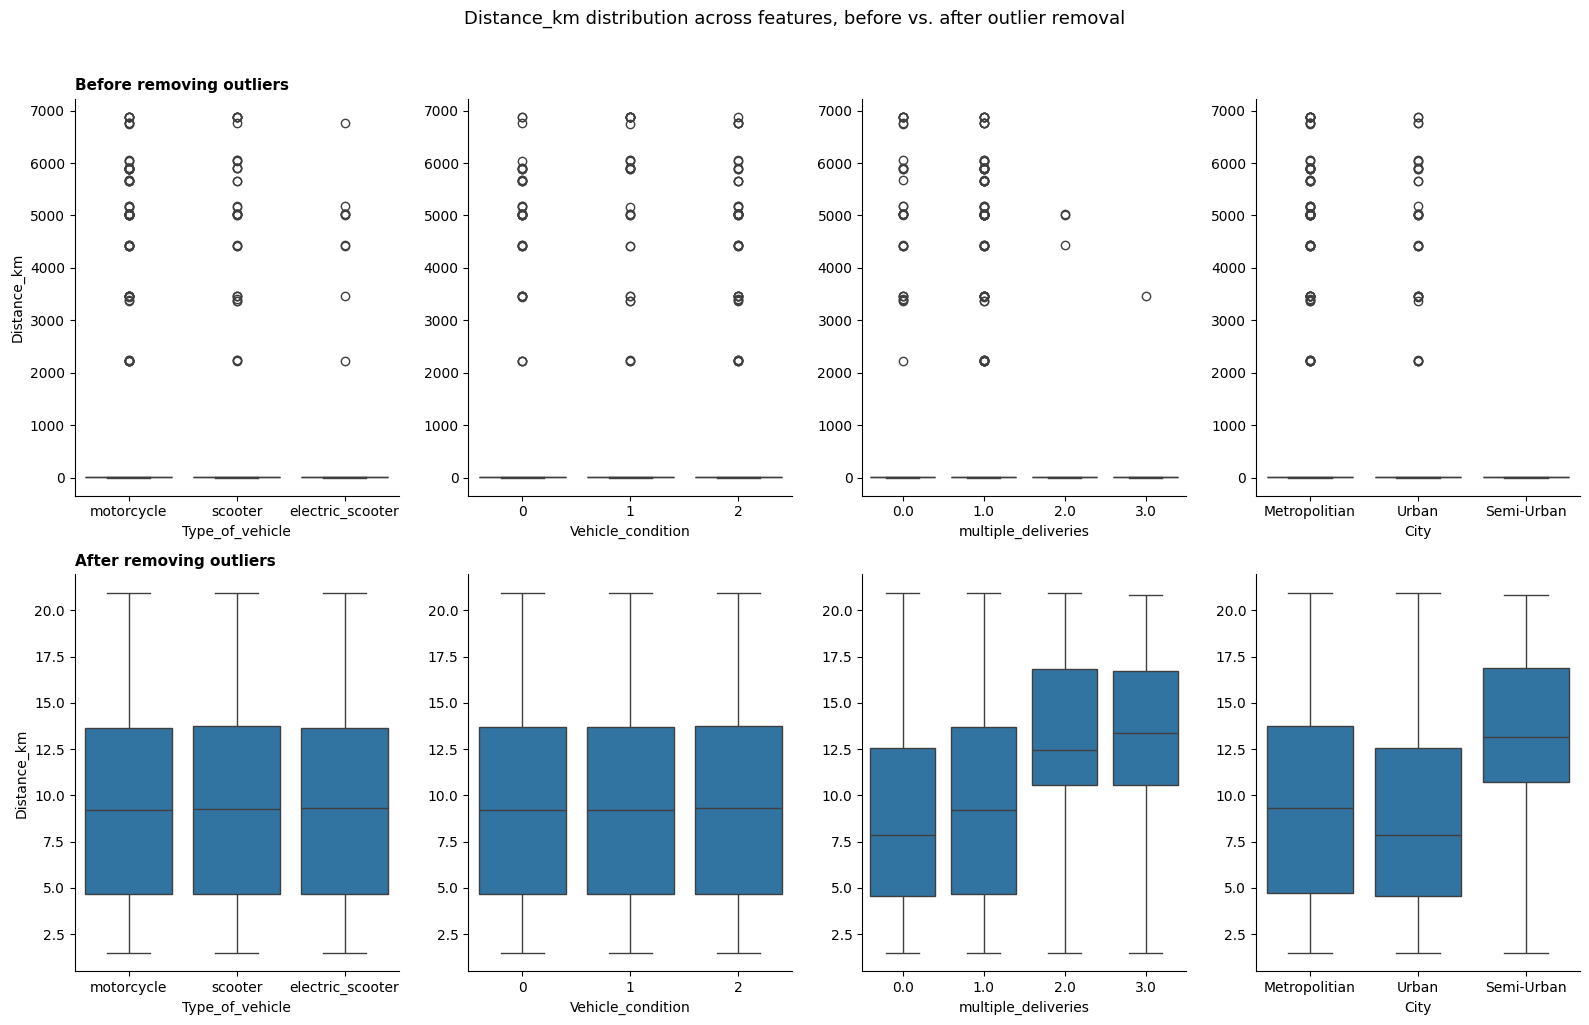

In [28]:
# Visual check: Distance_km vs. other features
fig, axes = plt.subplots(2,4, figsize=(16,10))

datasets = {'X_train': X_train, 'X_train_clean': X_train_clean}
feat_name = ['Type_of_vehicle', 'Vehicle_condition', 'multiple_deliveries', 'City']

for row, (name, df) in enumerate(datasets.items()):
    for col, feat in enumerate(feat_name):
        sns.boxplot(data=df, x=feat, y='Distance_km', ax=axes[row, col])
        if col == 0:
            axes[row, col].set_ylabel('Distance_km')
        else:
            axes[row, col].set_ylabel('')
        # remove top/right spines for a cleaner look
        axes[row, col].spines['top'].set_visible(False)
        axes[row, col].spines['right'].set_visible(False)

axes[0, 0].set_title('Before removing outliers', fontsize=11, fontweight='bold', loc='left')
axes[1, 0].set_title('After removing outliers', fontsize=11, fontweight='bold', loc='left')

fig.suptitle('Distance_km distribution across features, before vs. after outlier removal', 
             fontsize=13, y=1.02)

plt.tight_layout()
plt.show()

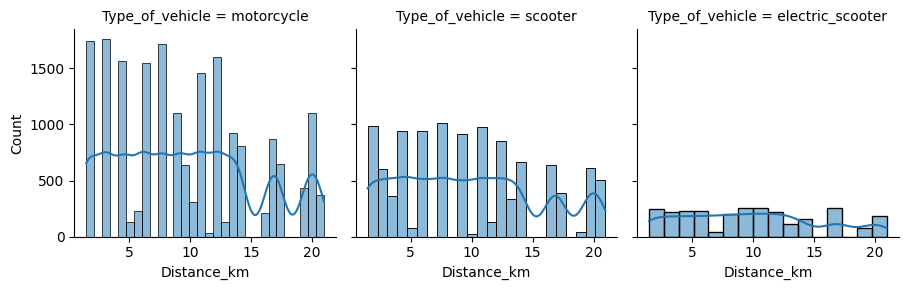

In [29]:
g = sns.FacetGrid(X_train_clean, col='Type_of_vehicle', col_wrap=4)
g.map(sns.histplot, 'Distance_km', kde=True)
plt.show()

#### 8. EDA

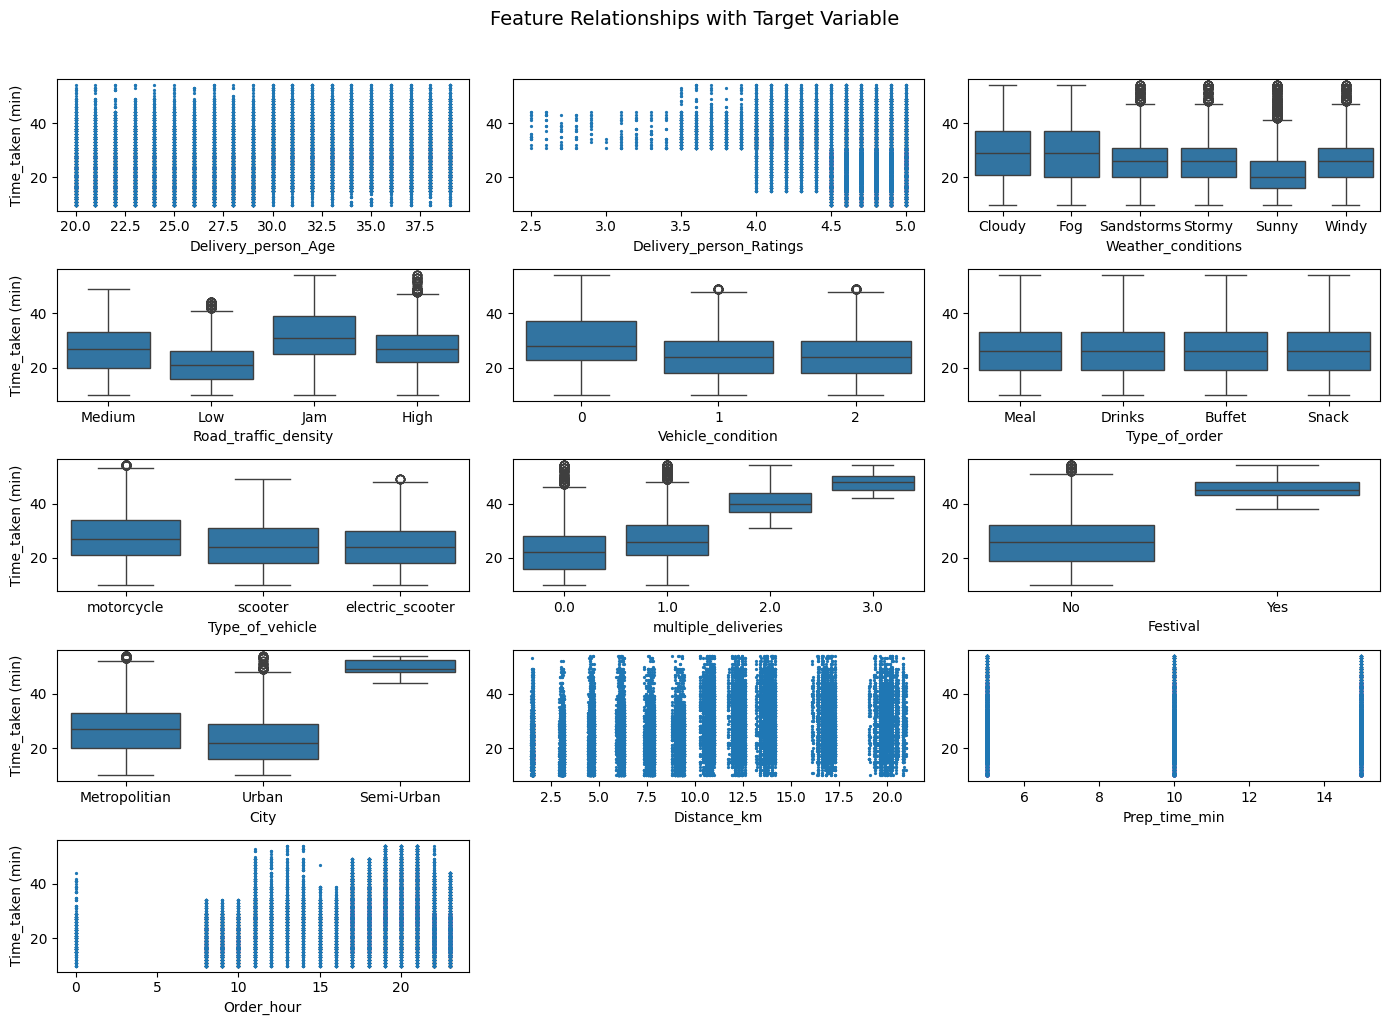

In [31]:
# 1. Cross plot: feature vs. target relationships
ncols = 3
nrows = int(np.ceil(len(feature_labels) / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(14, 10))
axs = axs.flatten()

for k, feat in enumerate(feature_labels):

    if feat in cat_cols:
        sns.boxplot(x=X_train_clean[feat], y=y_train_clean, ax=axs[k])
    else:
        axs[k].scatter(X_train_clean[feat], y_train_clean, marker='.', s=7.0)
    
    axs[k].set_xlabel(feat)
    if k % 3 == 0:
        axs[k].set_ylabel(y_train.name)
    else:
        axs[k].set_ylabel('')

# remove unused subplots
for j in range(len(feature_labels), len(axs)):
    fig.delaxes(axs[j])
    
fig.suptitle('Feature Relationships with Target Variable', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

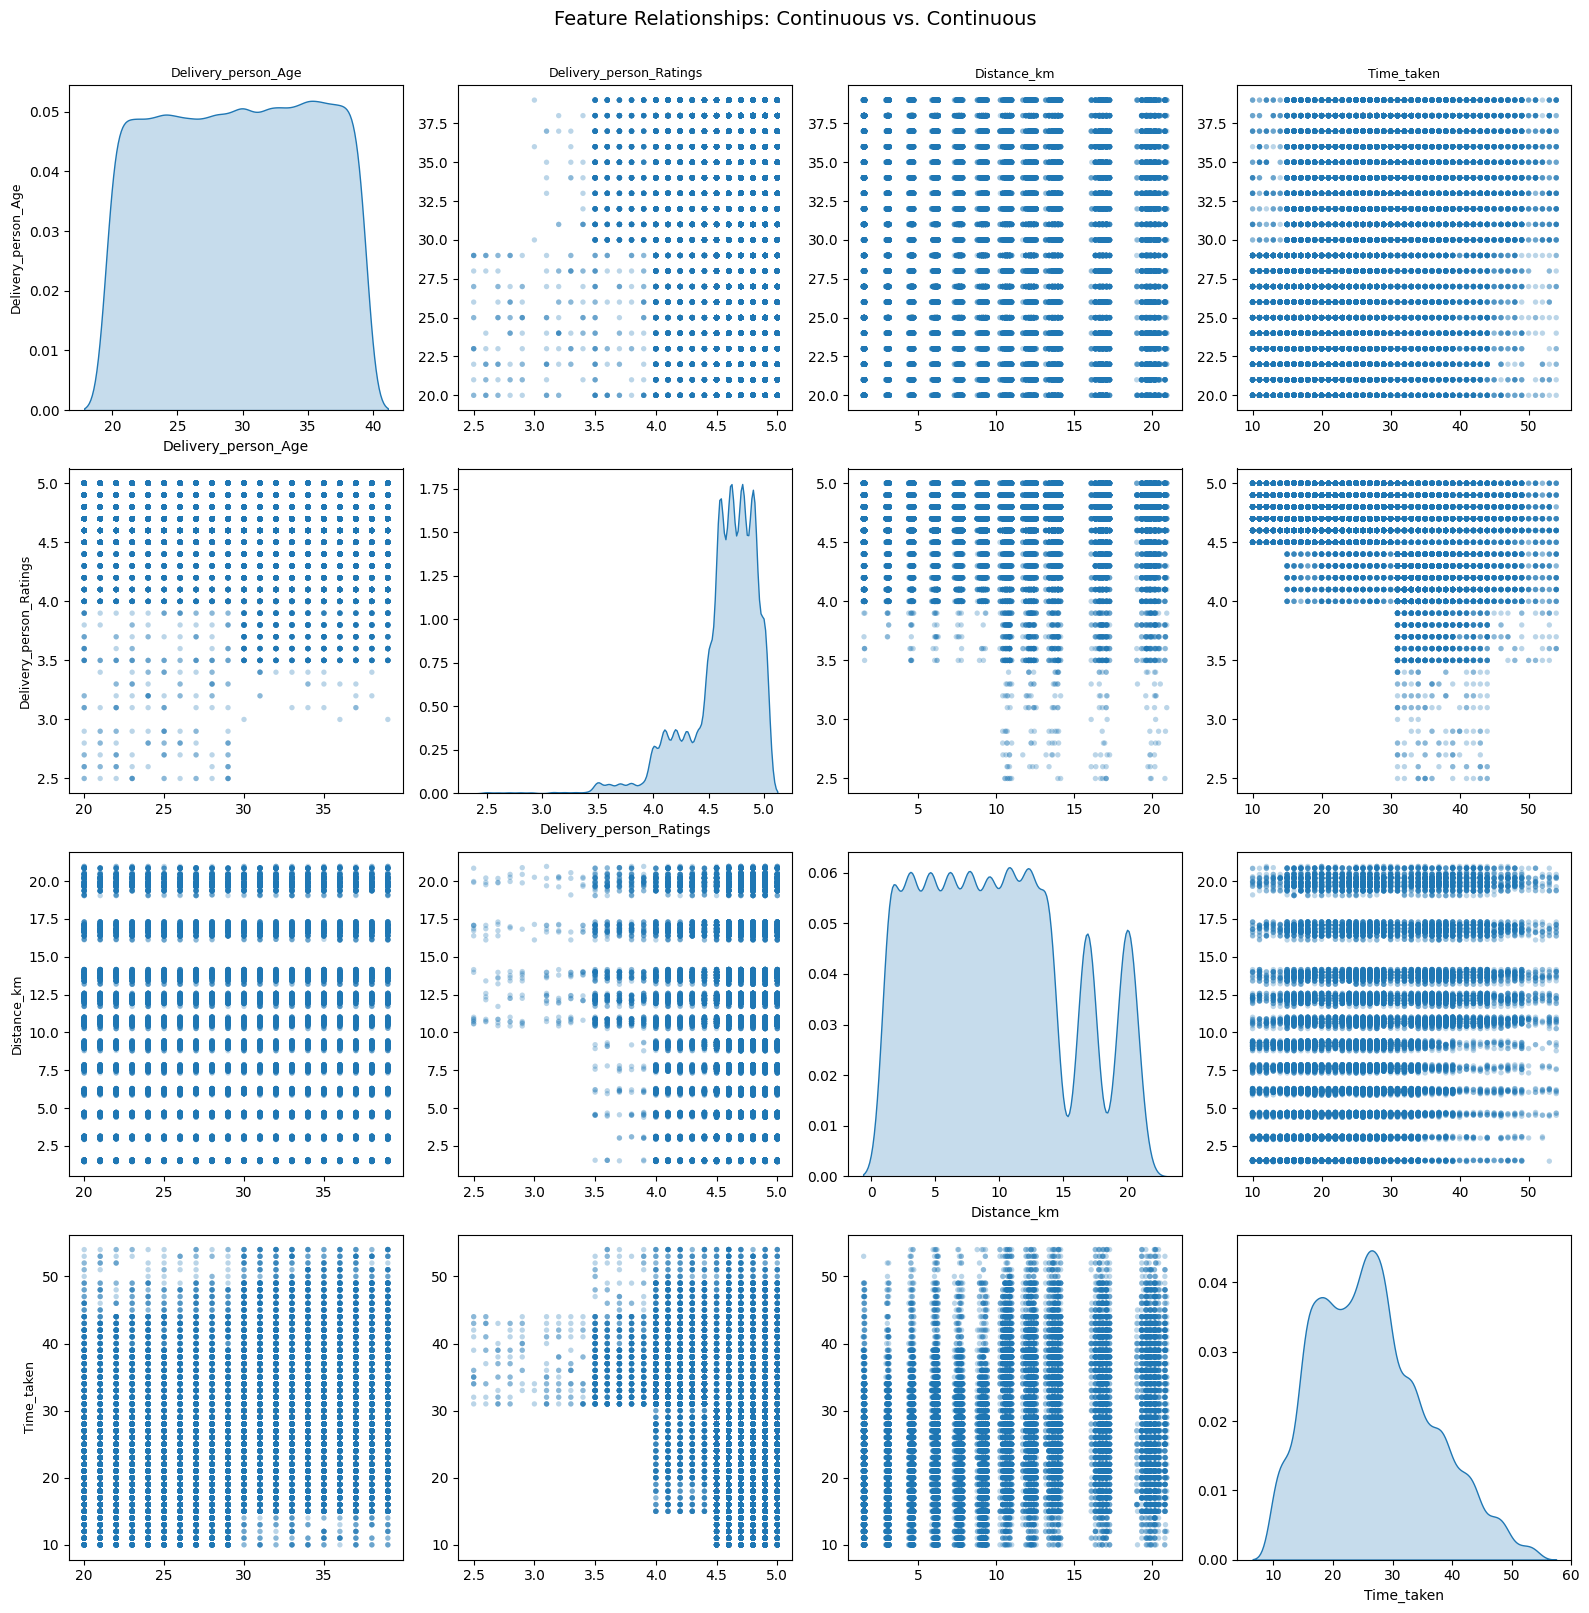

In [32]:
# 2. Pair plot: feature vs. feature relationships
# Combine X_train and y_train into one DataFrame
train_df = X_train_clean.copy()
train_df['Time_taken'] = y_train_clean

continuous_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Distance_km', 'Time_taken']
discrete_cols = ['Vehicle_condition', 'multiple_deliveries', 'Prep_time_min', 'Order_hour']
categorical_cols = ['Weather_conditions', 'Type_of_order', 'City', 'Festival', 'Road_traffic_density']

n_cont = len(continuous_cols)
n_disc = len(discrete_cols)
n_cat = len(categorical_cols)

# Pair plots
# Figure 1: Continuous vs Continuous (manual pairplot grid)
fig, axs = plt.subplots(n_cont, n_cont, figsize=(4*n_cont, 4*n_cont))

for row, rcol in enumerate(continuous_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[row, col]
        if row == col:
            sns.kdeplot(train_df[rcol], ax=ax, fill=True)
            ax.set_ylabel('')
        else:
            ax.scatter(train_df[ccol], train_df[rcol], alpha=0.3, s=15, edgecolor='none')
        if row == 0:
            ax.set_title(ccol, fontsize=9)
        if col == 0:
            ax.set_ylabel(rcol, fontsize=9)

fig.suptitle('Feature Relationships: Continuous vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

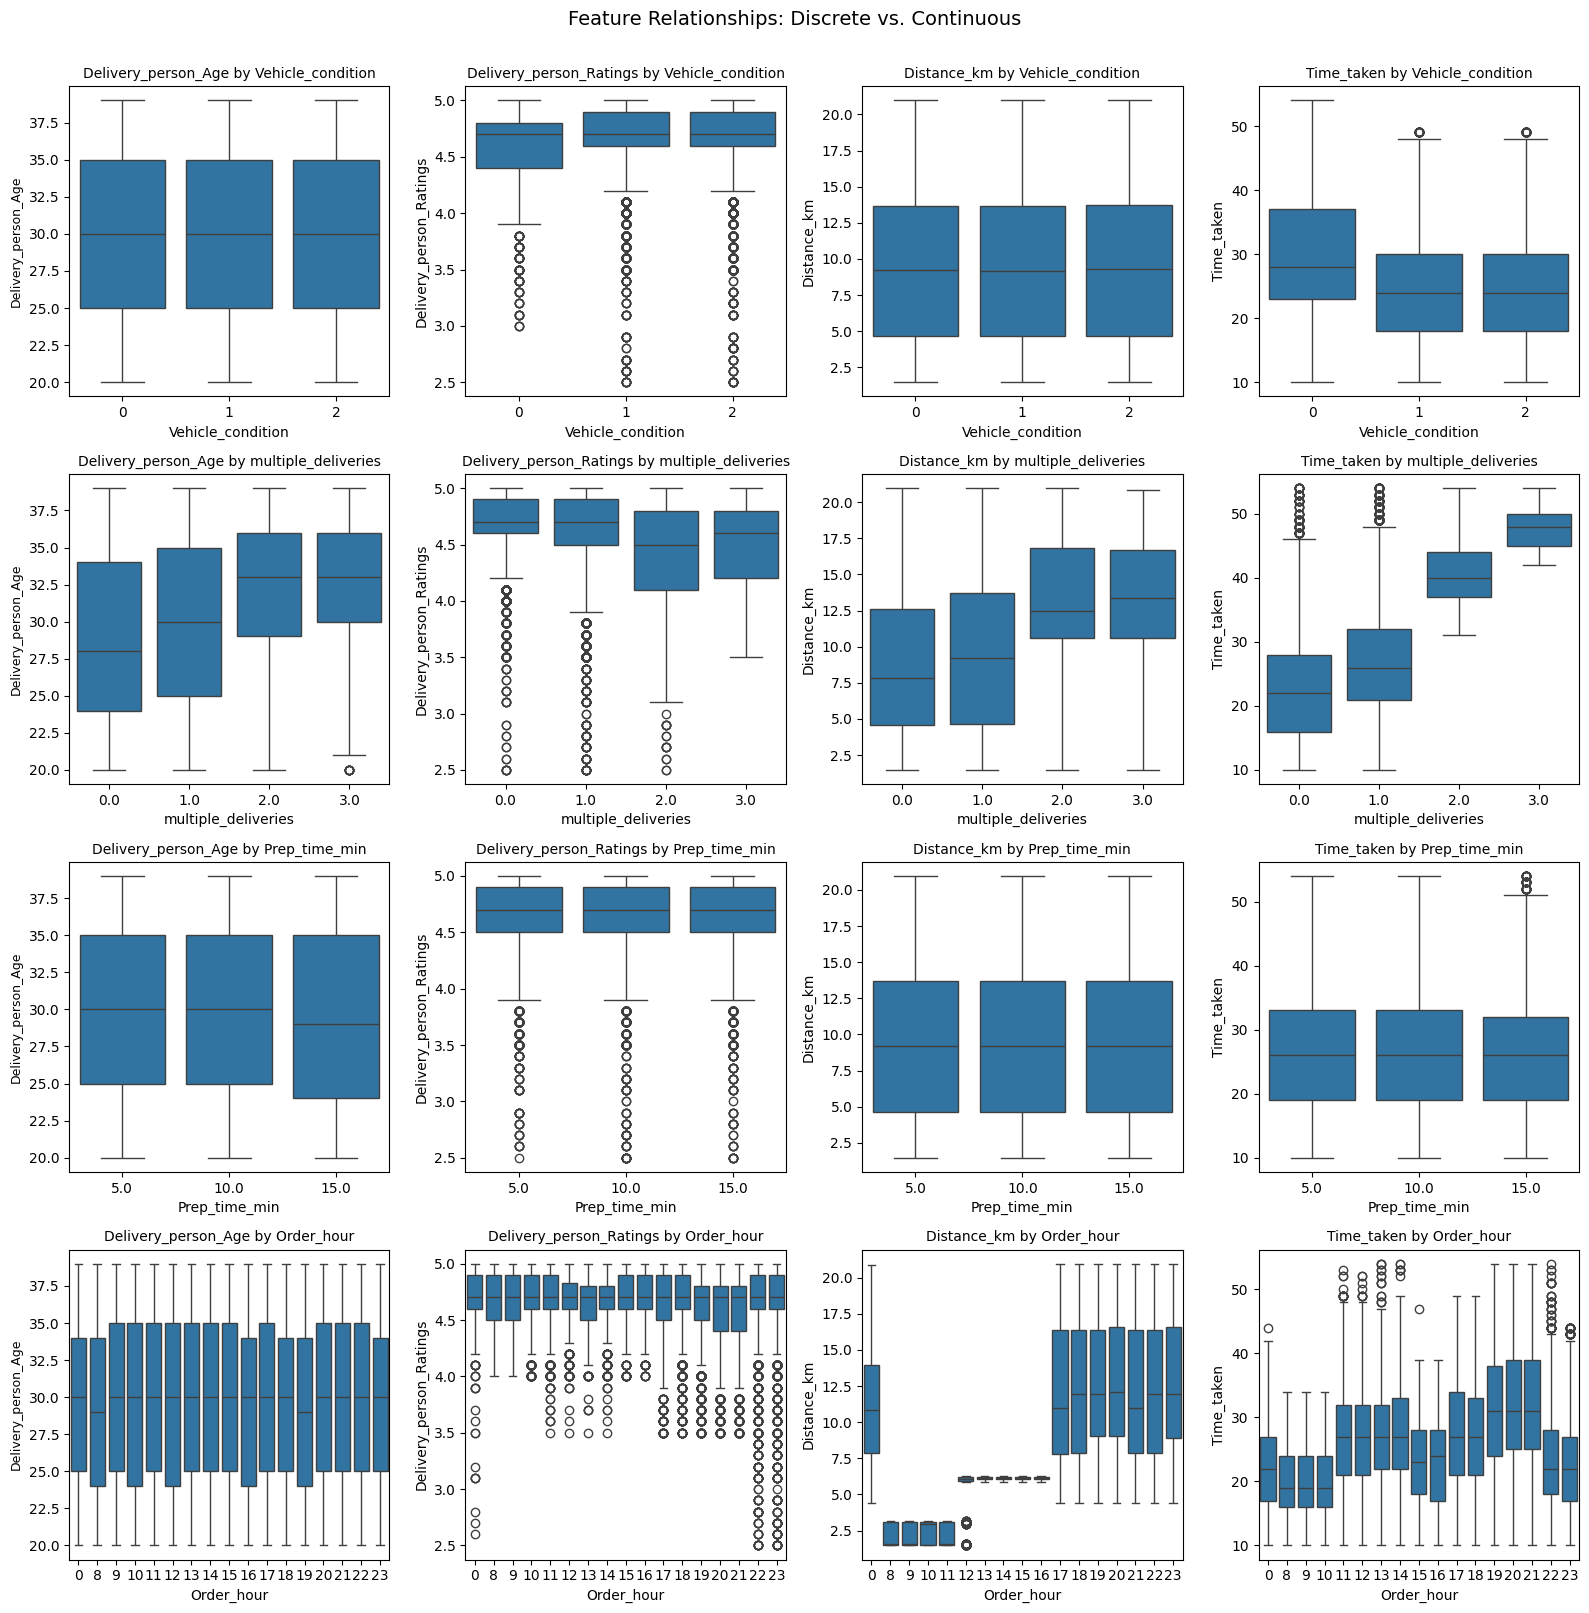

In [33]:
# Feature relationships
# Figure 2: Discrete vs Continuous (box plots)
fig, axs = plt.subplots(n_disc, n_cont, figsize=(4*n_cont, 4*n_disc))

for i, dcol in enumerate(discrete_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[i, col]
        sns.boxplot(x=dcol, y=ccol, data=train_df, ax=ax)
        ax.set_title(f'{ccol} by {dcol}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{ccol}', fontsize=9)

fig.suptitle('Feature Relationships: Discrete vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

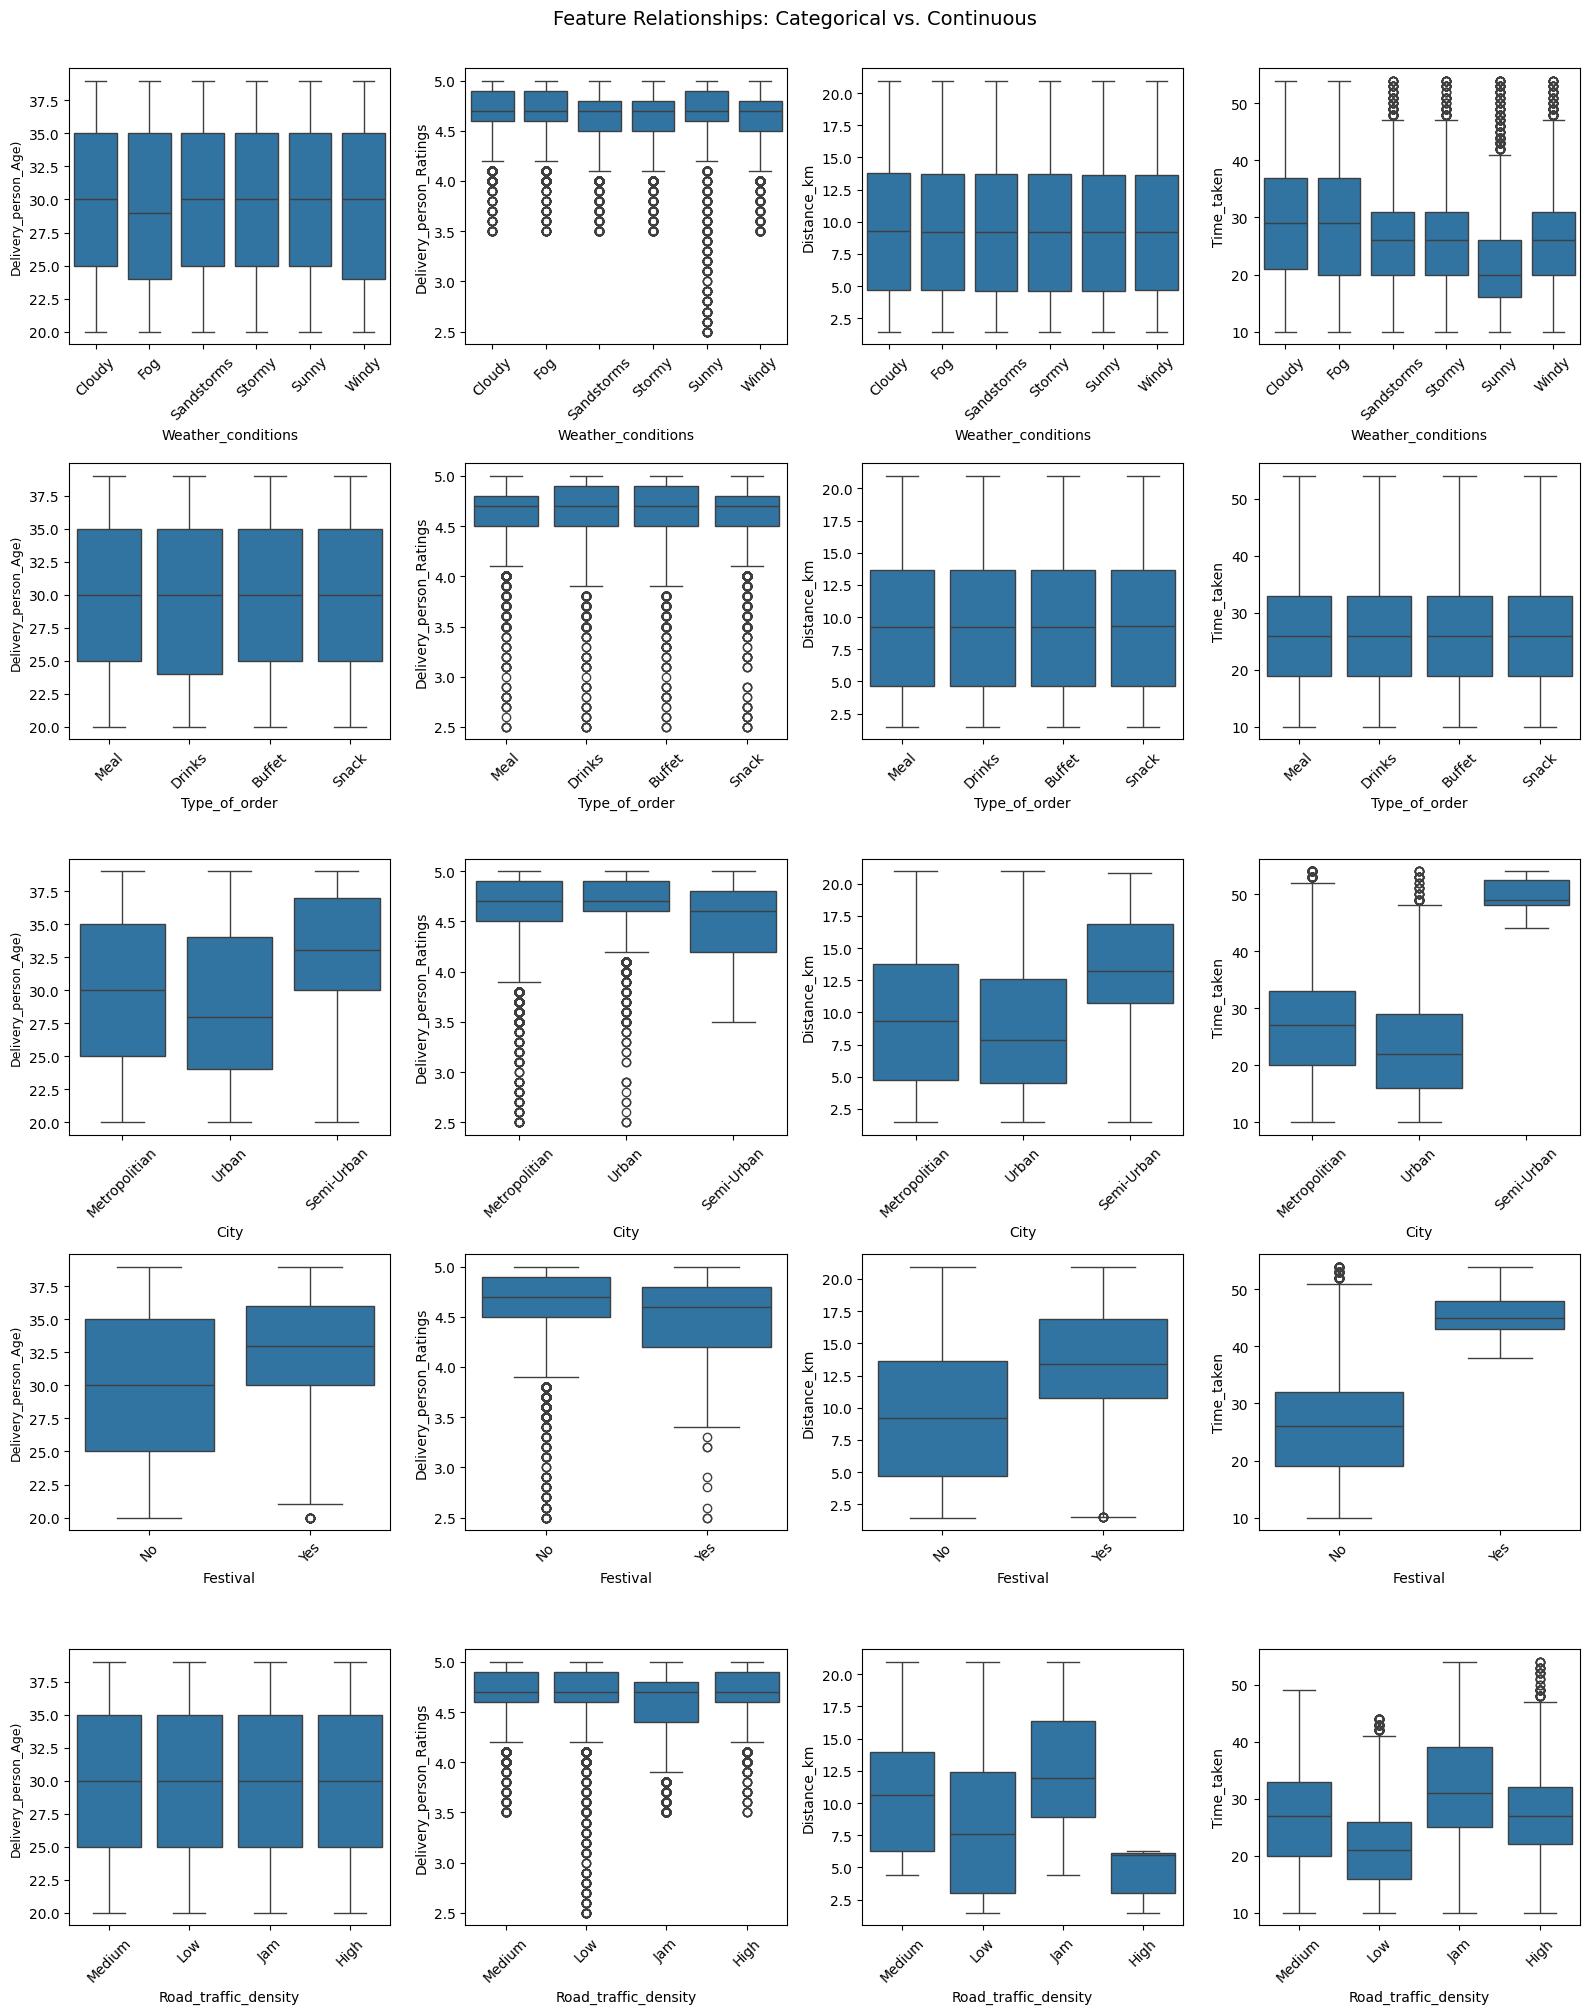

In [34]:
# Figure 3: Categorical vs Continuous (box plots, rotated labels)
fig, axs = plt.subplots(n_cat, n_cont, figsize=(4*n_cont, 4*n_cat))

for i, catcol in enumerate(categorical_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[i, col]
        sns.boxplot(x=catcol, y=ccol, data=train_df, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        if col == 0:
            ax.set_ylabel(f'{ccol})', fontsize=9)

fig.suptitle('Feature Relationships: Categorical vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

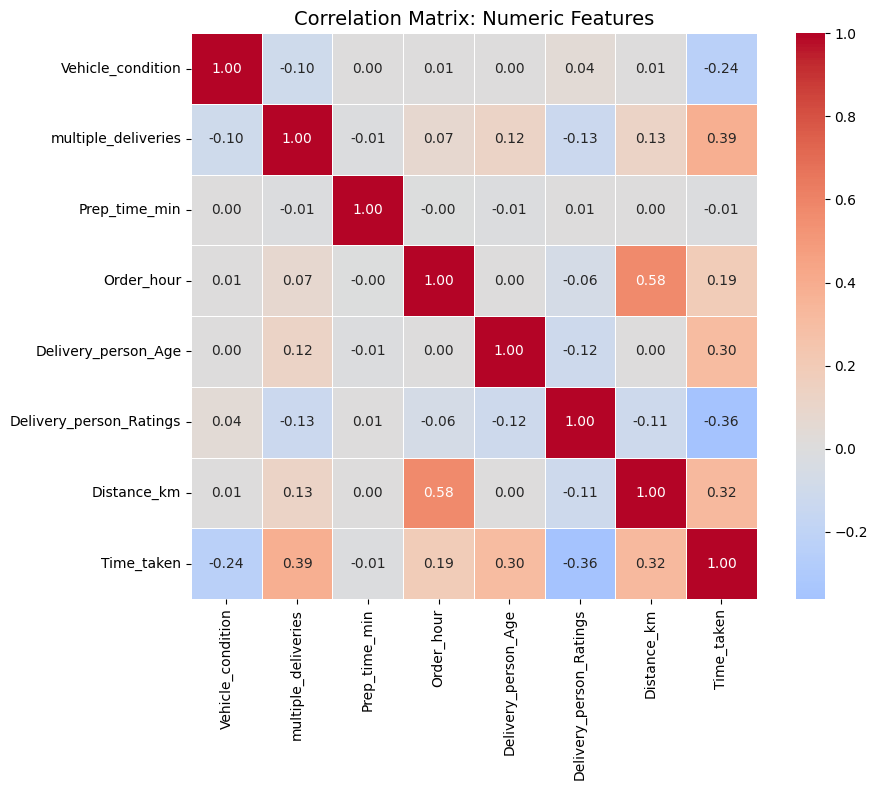

In [35]:
# 3. Correlation matrix
corr_matrix = train_df[discrete_cols + continuous_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

#### 9. Feature Encoding + Scaling

In [38]:
# 1. Cyclical encoding for Order_hour (do this FIRST, before ColumnTransformer)
for df in [X_train_clean, X_test_clean]:
    df['hour_sin'] = np.sin(2 * np.pi * df['Order_hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['Order_hour'] / 24)
    df.drop(columns=['Order_hour'], inplace=True)

# 2. Binary encoding
for df in [X_train_clean, X_test_clean]:
    df['Festival'] = df['Festival'].map({'No': 0, 'Yes': 1})

# 3. Organize columns
norm_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 
             'Distance_km', 'Prep_time_min',
             'hour_sin', 'hour_cos']  # continuous / cyclical (already -1 to 1)

onehot_cols = ['Weather_conditions', 'Type_of_order', 'Type_of_vehicle', 'City']

ordinal_cols = ['Road_traffic_density']  # only string-based ordinal needs encoding
ordinal_order = [['Low', 'Medium', 'High', 'Jam']]

# 4. ColumnTransformer: one-hot + ordinal + (optional) scaling
preprocessor_norm = ColumnTransformer(transformers=[
    ('num', StandardScaler(), norm_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
], remainder='passthrough')  # Vehicle_condition, multiple_deliveries, Festival pass through

# No scaling — for tree-based models (still uses hour_sin/hour_cos, not raw Order_hour)
preprocessor_raw = ColumnTransformer(transformers=[
    ('num', 'passthrough', norm_cols), 
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
], remainder='passthrough')



In [ ]:
# 5. Fit on train, transform both train/test
X_train_encoded_norm = preprocessor_norm.fit_transform(X_train_clean)
X_test_encoded_norm  = preprocessor_norm.transform(X_test_clean)

X_train_encoded_raw = preprocessor_raw.fit_transform(X_train_clean)
X_test_encoded_raw  = preprocessor_raw.transform(X_test_clean)

# 6. Check shapes of encoded datasets
X_train_encoded_norm.shape, X_test_encoded_norm.shape, X_train_encoded_raw.shape, X_test_encoded_raw.shape

# Part 2: Model Training

In [ ]:
# KFold split training into 5 sets
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# function to evaluate and print cv results
def evaluate_cv(model, in_X, in_y, cv):
    cv_results = cross_validate(
        model, in_X, in_y, cv=cv,
        scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_percentage_error'],
        return_train_score=True
    )

    # mean cv results
    cv_mae  = -cv_results['test_neg_mean_absolute_error'].mean()
    cv_rmse = -cv_results['test_neg_root_mean_squared_error'].mean()
    cv_r2   =  cv_results['test_r2'].mean()
    cv_mape = -cv_results['test_neg_mean_absolute_percentage_error'].mean()

    # mean cv train results
    cv_train_mae  = -cv_results['train_neg_mean_absolute_error'].mean()
    cv_train_rmse = -cv_results['train_neg_root_mean_squared_error'].mean()
    cv_train_r2   =  cv_results['train_r2'].mean()
    cv_train_mape = -cv_results['train_neg_mean_absolute_percentage_error'].mean()
    
    result = {
        'model_name': type(model).__name__,
        'cv_train_MAE': cv_train_mae, 'cv_train_RMSE': cv_train_rmse,
        'cv_train_R2': cv_train_r2, 'cv_train_MAPE': cv_train_mape,
        'cv_MAE': cv_mae, 'cv_RMSE': cv_rmse,
        'cv_R2': cv_r2, 'cv_MAPE': cv_mape,
    }

    summary_df = pd.DataFrame([result])
    formatters = {
        'cv_train_MAE': '{:.2f}'.format, 'cv_MAE': '{:.2f}'.format,
        'cv_train_RMSE': '{:.2f}'.format, 'cv_RMSE': '{:.2f}'.format,
        'cv_train_R2': '{:.2%}'.format, 'cv_R2': '{:.2%}'.format,
        'cv_train_MAPE': '{:.2%}'.format, 'cv_MAPE': '{:.2%}'.format,
    }
    print(summary_df.to_string(index=False, formatters=formatters))

    # result per fold
    print('\n\ncv MAE and RMSE Per Fold:\n')

    cv_mae_folds = -cv_results['test_neg_mean_absolute_error']
    cv_mae_std = cv_mae_folds.std()

    cv_rmse_folds = -cv_results['test_neg_root_mean_squared_error']
    cv_rmse_std = cv_rmse_folds.std()

    n_folds = len(cv_mae_folds)
    fold_cols = [f'cv_{i+1}' for i in range(n_folds)]

    per_fold_df = pd.DataFrame(
        [
            list(cv_mae_folds) + [cv_mae, cv_mae_std],
            list(cv_rmse_folds) + [cv_rmse, cv_rmse_std],
        ],
        columns=fold_cols + ['cv_mean', 'cv_std'],
        index=['cv_MAE', 'cv_RMSE']
    )

    cols_to_format = [c for c in per_fold_df.columns if c != 'cv_std']
    per_fold_df[cols_to_format] = per_fold_df[cols_to_format].map(lambda x: f'{x:.2f}')
    
    print(per_fold_df.to_string())

    result['result_per_fold'] = per_fold_df
    
    return result


    

### 1. Linear Regression

#### Baseline Model

In [51]:
# cv scores of Linear Regression
reg_cv_score = evaluate_cv(LinearRegression(), X_train_encoded_norm, y_train_clean, kf)

      model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
LinearRegression         4.71          5.91      59.88%        20.61%   4.71    5.92 59.80%  20.62%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   4.70  4.72  4.69  4.76  4.69    4.71  0.026623
cv_RMSE  5.93  5.93  5.91  5.95  5.88    5.92  0.026306


In [52]:
# fit final baseline model
reg_final = LinearRegression().fit(X_train_encoded_norm, y_train_clean)
reg_pred = reg_final.predict(X_train_encoded_norm)

In [53]:
# baseline model: intercepts and coefficients
print("Intercept:", reg_final.intercept_)
print("Coefficients:")
feature_names = preprocessor_norm.get_feature_names_out()
coefs = pd.Series(reg_final.coef_, index=feature_names).sort_index()
print(coefs)

Intercept: 26.357002025934413
Coefficients:
num__Delivery_person_Age                    2.204467
num__Delivery_person_Ratings               -2.323750
num__Distance_km                            2.035957
num__Prep_time_min                         -0.012038
num__hour_cos                              -0.897514
num__hour_sin                              -0.426104
onehot__City_Metropolitian                 -2.597672
onehot__City_Semi-Urban                     7.047402
onehot__City_Urban                         -4.449730
onehot__Type_of_order_Buffet               -0.023128
onehot__Type_of_order_Drinks               -0.042541
onehot__Type_of_order_Meal                  0.000045
onehot__Type_of_order_Snack                 0.065624
onehot__Type_of_vehicle_electric_scooter    0.467981
onehot__Type_of_vehicle_motorcycle          0.022441
onehot__Type_of_vehicle_scooter            -0.490422
onehot__Weather_conditions_Cloudy           2.369789
onehot__Weather_conditions_Fog              2.502876
on

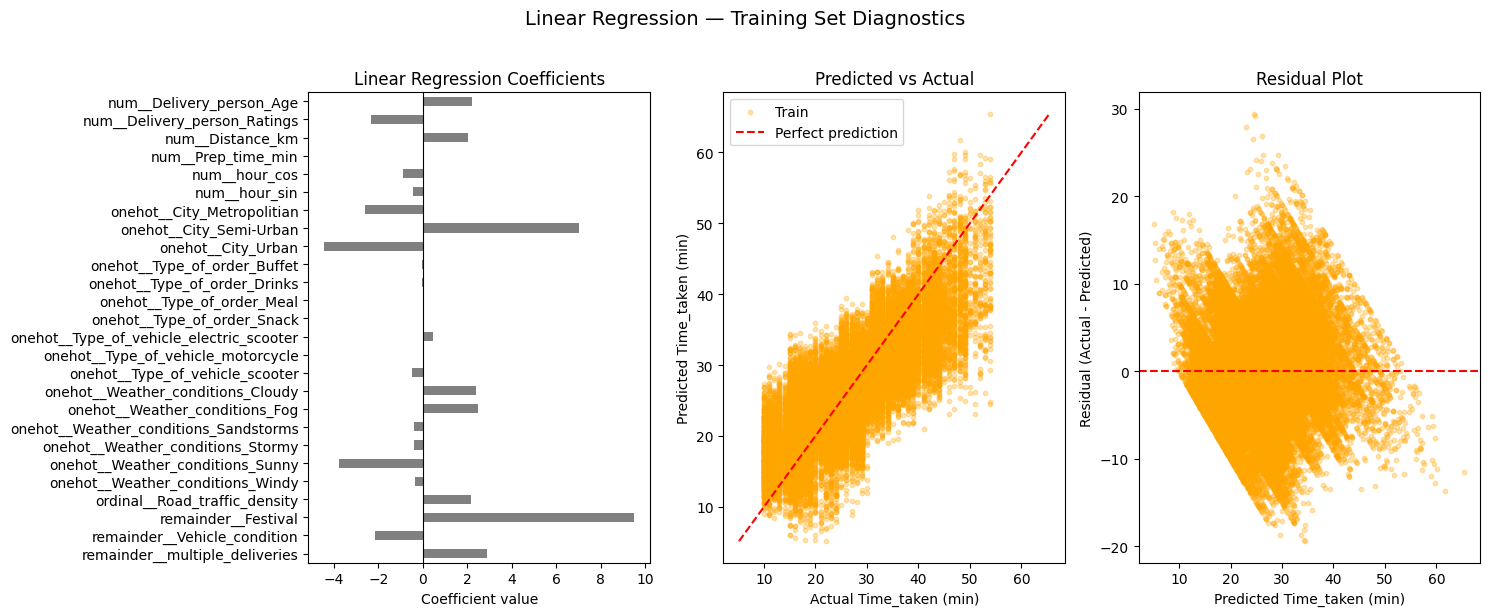

In [54]:
# plots
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# 1. Coefficients 
coefs.sort_index(ascending=False).plot(kind='barh', ax=axes[0], color='gray')
axes[0].set_xlabel('Coefficient value')
axes[0].set_title('Linear Regression Coefficients')
axes[0].axvline(0, color='black', linewidth=0.8)

# 2. Predicted vs. Actual (training data only)
axes[1].scatter(y_train_clean, reg_pred, alpha=0.3, s=10, color='orange', label='Train')

lims = [min(y_train_clean.min(), reg_pred.min()), max(y_train_clean.max(), reg_pred.max())]
axes[1].plot(lims, lims, 'r--', label='Perfect prediction')

axes[1].set_xlabel('Actual Time_taken (min)')
axes[1].set_ylabel('Predicted Time_taken (min)')
axes[1].set_title('Predicted vs Actual')
axes[1].legend()

# 3. Residual plot (training data only)
residuals = y_train_clean - reg_pred
axes[2].scatter(reg_pred, residuals, alpha=0.3, s=10, color='orange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted Time_taken (min)')
axes[2].set_ylabel('Residual (Actual - Predicted)')
axes[2].set_title('Residual Plot')

fig.suptitle('Linear Regression — Training Set Diagnostics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#### RidgeCV

In [57]:
# lambdas
lambdas = np.logspace(-6, 3, 500) #[x/50 for x in range(1,5000)]

# RidgeCV to search the best lambda
ridge_cv = RidgeCV(alphas=lambdas, cv=kf, scoring='neg_mean_absolute_error')
ridge_cv.fit(X_train_encoded_norm, y_train_clean)

# print the best alpha
print(f"Best alpha: {ridge_cv.alpha_}")
print(f"Grid range: [{min(lambdas)}, {max(lambdas)}]")

if ridge_cv.alpha_ <= min(lambdas) * 1.5:
    print("⚠️ Best alpha is near the LOWER edge — consider extending the grid downward.")
elif ridge_cv.alpha_ >= max(lambdas) * 0.95:
    print("⚠️ Best alpha is near the UPPER edge — consider extending the grid upward.")
else:
    print("✅ Best alpha looks like an interior optimum.")

Best alpha: 1e-06
Grid range: [1e-06, 1000.0]
⚠️ Best alpha is near the LOWER edge — consider extending the grid downward.


In [58]:
# ridge cv score
ridge_cv_score = evaluate_cv(Ridge(alpha=ridge_cv.alpha_), X_train_encoded_norm, y_train_clean, kf)

model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
     Ridge         4.71          5.91      59.88%        20.61%   4.71    5.92 59.80%  20.62%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   4.70  4.72  4.69  4.76  4.69    4.71  0.026623
cv_RMSE  5.93  5.93  5.91  5.95  5.88    5.92  0.026306


In [59]:
# final ridge model
ridge_final = Ridge(alpha=ridge_cv.alpha_).fit(X_train_encoded_norm, y_train_clean)

#### LassoCV

In [60]:
# lambda lasso
lambdas_lasso = np.logspace(-6, 3, 200)

# Lasso CV
lasso_cv = LassoCV(alphas=lambdas_lasso, cv=kf)
lasso_cv.fit(X_train_encoded_norm, y_train_clean)

# print best alpha
print("Best alpha:", lasso_cv.alpha_)
print(f"Grid range: [{min(lambdas_lasso)}, {max(lambdas_lasso)}]")

if lasso_cv.alpha_ <= min(lambdas_lasso) * 1.5:
    print("⚠️ Best alpha is near the LOWER edge — consider extending the grid downward.")
elif lasso_cv.alpha_ >= max(lambdas_lasso) * 0.95:
    print("⚠️ Best alpha is near the UPPER edge — consider extending the grid upward.")
else:
    print("✅ Best alpha looks like an interior optimum.")

Best alpha: 0.001320088400831418
Grid range: [1e-06, 1000.0]
✅ Best alpha looks like an interior optimum.


In [61]:
print("Intercept:", lasso_cv.intercept_)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)
print("Coefficients:\n", lasso_coefs[lasso_coefs != 0])

Intercept: 23.400851235568105
Coefficients:
 num__Delivery_person_Age                    2.204313
num__Delivery_person_Ratings               -2.323160
num__Distance_km                            2.035093
num__Prep_time_min                         -0.010699
num__hour_sin                              -0.424018
num__hour_cos                              -0.894229
onehot__Weather_conditions_Cloudy           2.735772
onehot__Weather_conditions_Fog              2.868873
onehot__Weather_conditions_Sandstorms      -0.001080
onehot__Weather_conditions_Stormy          -0.000018
onehot__Weather_conditions_Sunny           -3.394400
onehot__Weather_conditions_Windy            0.026304
onehot__Type_of_order_Buffet               -0.011989
onehot__Type_of_order_Drinks               -0.032061
onehot__Type_of_order_Meal                  0.000007
onehot__Type_of_order_Snack                 0.066305
onehot__Type_of_vehicle_electric_scooter    0.422467
onehot__Type_of_vehicle_scooter            -0.514232
o

In [62]:
# lasso cv score
lasso_cv_score = evaluate_cv(Lasso(alpha=lasso_cv.alpha_), X_train_encoded_norm, y_train_clean, kf)

model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
     Lasso         4.71          5.91      59.88%        20.61%   4.71    5.92 59.80%  20.63%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   4.70  4.72  4.69  4.76  4.69    4.71  0.026469
cv_RMSE  5.93  5.93  5.91  5.95  5.87    5.92  0.026285


In [63]:
# final lasso model
lasso_final = Lasso(alpha=lasso_cv.alpha_).fit(X_train_encoded_norm, y_train_clean)

### 2. Tree-based

#### Random Forest

In [80]:
# Grid Search CV 
rf_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
}

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_grid,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,      # use all CPU cores — RF grid search is slow, this helps a lot
    verbose=1
)

rf_search.fit(X_train_encoded_raw, y_train_clean)   

# Best parameters
print("Best params:", rf_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 300}


In [81]:
# cv scores
rf_optimal_cv_score = evaluate_cv(RandomForestRegressor(random_state=42, **rf_search.best_params_), X_train_encoded_raw, y_train_clean, kf)

           model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
RandomForestRegressor         2.57          3.20      88.27%        10.96%   3.04    3.78 83.62%  12.99%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   3.03  3.04  3.04  3.05  3.06    3.04  0.008351
cv_RMSE  3.76  3.76  3.82  3.77  3.77    3.78  0.019611


In [82]:
# optimal model
rf_optimal = RandomForestRegressor(random_state=42, **rf_search.best_params_).fit(X_train_encoded_raw, y_train_clean)

<Axes: >

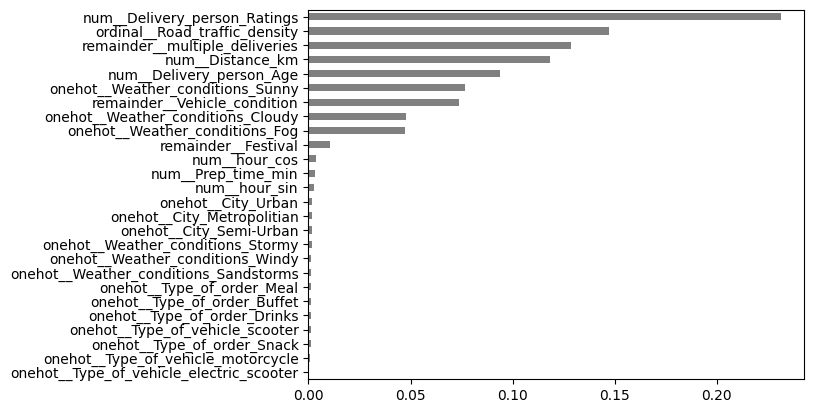

In [83]:
# feature importances of optimal model
pd.Series(rf_optimal.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='gray')

#### XGBoost

In [84]:
# XGBoost Randomized Search
xgb_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=xgb_grid,
    n_iter=25,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_search.fit(X_train_encoded_raw, y_train_clean)

# Best parameters
print("Best XGB params:", xgb_search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [85]:
# XGB cv scores
xgb_optimal_cv_score = evaluate_cv(XGBRegressor(random_state=42, **xgb_search.best_params_), X_train_encoded_raw, y_train_clean, kf)

  model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
XGBRegressor         2.84          3.53      85.67%        12.25%   3.03    3.77 83.70%  13.01%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   3.01  3.03  3.05  3.06  3.03    3.03  0.017757
cv_RMSE  3.75  3.74  3.81  3.79  3.75    3.77  0.027333


In [86]:
# fit optimal model
xgb_optimal = XGBRegressor(random_state=42, **xgb_search.best_params_).fit(X_train_encoded_raw, y_train_clean)

<Axes: >

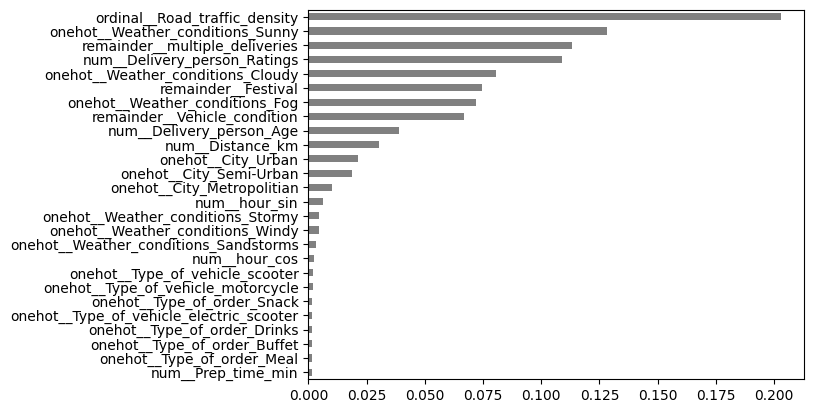

In [87]:
# feature importances
pd.Series(xgb_optimal.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='gray')

#### LightGBM

In [88]:
# Randomized Search CV
lgbm_grid_wide = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 30, 50],
}

lgbm_random = RandomizedSearchCV(
    LGBMRegressor(random_state=42, force_row_wise=True, verbose=-1),
    param_distributions=lgbm_grid_wide,
    n_iter=25,          # test 25 random combinations instead of all ~2000+ possible
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
lgbm_random.fit(X_train_encoded_raw, y_train_clean)

# Best parameters
print("Best LightGBM params:", lgbm_random.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best LightGBM params: {'num_leaves': 63, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.05}


In [89]:
# LightGBM optimal cv score
lgbm_optimal_cv_score = evaluate_cv(LGBMRegressor(random_state=42, **lgbm_random.best_params_), X_train_encoded_raw, y_train_clean, kf)

   model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
LGBMRegressor         2.88          3.54      85.59%        12.41%   2.99    3.70 84.32%  12.83%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   2.98  2.99  3.00  3.01  2.98    2.99  0.010266
cv_RMSE  3.68  3.68  3.73  3.71  3.68    3.70  0.022583


In [90]:
# fit optimal LightGBM model
lgbm_optimal = LGBMRegressor(random_state=42, **lgbm_random.best_params_).fit(X_train_encoded_raw, y_train_clean)

<Axes: >

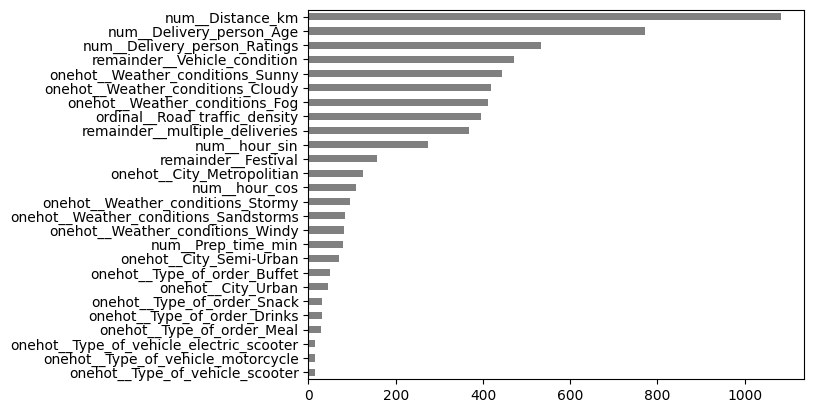

In [91]:
# feature importances
pd.Series(lgbm_optimal.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='gray')

#### CatBoost

In [92]:
# RandomizedSearchCV CatBoost
cat_grid = {
    'n_estimators': [100, 200, 300, 500],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'l2_leaf_reg': [1, 3, 5, 10, 20],
}

cat_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    param_distributions=cat_grid,
    n_iter=20,                 # number of random combinations to try (instead of all of them)
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,           # makes the random sampling reproducible
    verbose=1
)
cat_search.fit(X_train_encoded_raw, y_train_clean)

# Best parameters
print("Best CatBoost params:", cat_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CatBoost params: {'n_estimators': 200, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'depth': 8}


In [93]:
# cv scores
cat_optimal_cv_score = evaluate_cv(CatBoostRegressor(random_state=42, verbose=0, **cat_search.best_params_), 
                                    X_train_encoded_raw, y_train_clean, kf)

       model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
CatBoostRegressor         2.74          3.40      86.77%        11.78%   2.99    3.70 84.27%  12.79%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   2.98  2.97  3.00  3.01  2.99    2.99  0.015081
cv_RMSE  3.68  3.67  3.74  3.71  3.71    3.70  0.023126


In [94]:
# final model
cat_optimal = CatBoostRegressor(random_state=42, verbose=0, **cat_search.best_params_).fit(X_train_encoded_raw, y_train_clean)

#### CatBoost Native

In [95]:
# categorical features
cat_features = ['Weather_conditions', 'Type_of_order', 'Type_of_vehicle', 'City', 'Road_traffic_density']

# RandomizedSearchCV
cat_grid = {
    'n_estimators': [100, 200, 300, 500],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'l2_leaf_reg': [1, 3, 5, 10, 20],
}

cat_native_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    param_distributions=cat_grid,
    n_iter=20,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Pass cat_features as a fit param — GridSearchCV/RandomizedSearchCV forward **fit_params to estimator.fit()
cat_native_search.fit(X_train_clean, y_train_clean, cat_features=cat_features)

# Best parameters
print("Best CatBoost native params:", cat_native_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CatBoost native params: {'n_estimators': 200, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'depth': 8}


In [96]:
# to add cat_features
class CatBoostNativeWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, cat_features=None, **catboost_params):
        self.cat_features = cat_features
        self.catboost_params = catboost_params

    def fit(self, X, y):   # <-- only takes X, y — matches what print_result_cv calls
        self.model_ = CatBoostRegressor(**self.catboost_params)
        self.model_.fit(X, y, cat_features=self.cat_features, verbose=0)  # cat_features pulled from self, not from the caller
        return self

    def predict(self, X):
        return self.model_.predict(X)


# cv score
cat_native_optimal_cv_score = evaluate_cv(
    CatBoostNativeWrapper(cat_features=cat_features, random_state=42, verbose=0, **cat_native_search.best_params_), X_train_clean, y_train_clean, kf)

           model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
CatBoostNativeWrapper         2.88          3.58      85.34%        12.36%   3.00    3.72 84.13%  12.83%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   2.98  2.98  3.01  3.02  2.99    3.00  0.015729
cv_RMSE  3.70  3.69  3.77  3.73  3.71    3.72  0.028243


In [97]:
# fit final model
cat_native_optimal = CatBoostRegressor(random_state=42, verbose=0, **cat_native_search.best_params_).fit(X_train_clean, 
                                                                                                        y_train_clean, 
                                                                                                        cat_features=cat_features)

<Axes: >

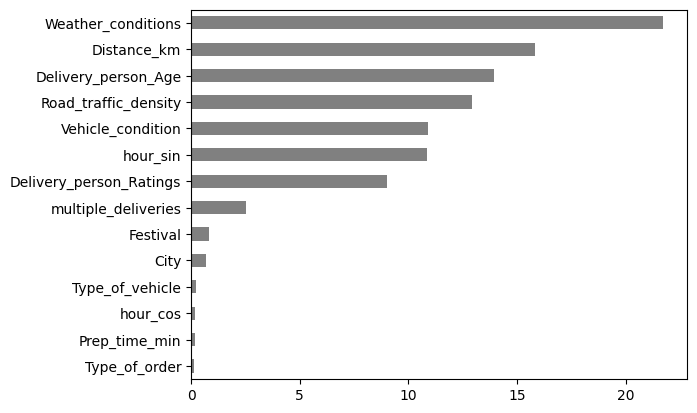

In [98]:
# feature importances
pd.Series(cat_native_optimal.feature_importances_, index=X_train_clean.columns).sort_values().plot(kind='barh', color='gray')

### 3. MLP

In [99]:
# RandomizedSearchCV 
mlp_grid = {
    'hidden_layer_sizes': [(32, 16), (64, 32), (128, 64), (100, 50), (64,), (100,)],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.005, 0.01],
    'activation': ['relu', 'tanh'],
}

mlp_search = RandomizedSearchCV(
    MLPRegressor(random_state=42, max_iter=1000, early_stopping=True, solver='adam'),
    param_distributions=mlp_grid,
    n_iter=15,          # fewer iterations than boosting models, given MLP's slower per-fit cost
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
mlp_search.fit(X_train_encoded_norm, y_train_clean)

# Best parameters
print("Best MLP params:", mlp_search.best_params_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best MLP params: {'learning_rate_init': 0.005, 'hidden_layer_sizes': (128, 64), 'alpha': 0.1, 'activation': 'tanh'}


In [100]:
mlp_best = MLPRegressor(
    random_state=42, max_iter=1000, early_stopping=True, solver='adam', 
    **mlp_search.best_params_
)

# optimal MLP cv scores
mlp_optimal_cv_score = evaluate_cv(mlp_best, X_train_encoded_norm, y_train_clean, kf)

  model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
MLPRegressor         2.90          3.58      85.27%        12.40%   3.07    3.82 83.30%  13.11%


cv MAE and RMSE Per Fold:

         cv_1  cv_2  cv_3  cv_4  cv_5 cv_mean    cv_std
cv_MAE   3.06  3.06  3.08  3.09  3.07    3.07  0.012266
cv_RMSE  3.80  3.78  3.85  3.84  3.81    3.82  0.026263


In [101]:
# Optimal model
mlp_optimal = MLPRegressor(
    random_state=42, max_iter=1000, early_stopping=True, solver='adam',
    **mlp_search.best_params_
).fit(X_train_encoded_norm, y_train_clean)

Converged in 31 iterations
Final loss: 6.7382


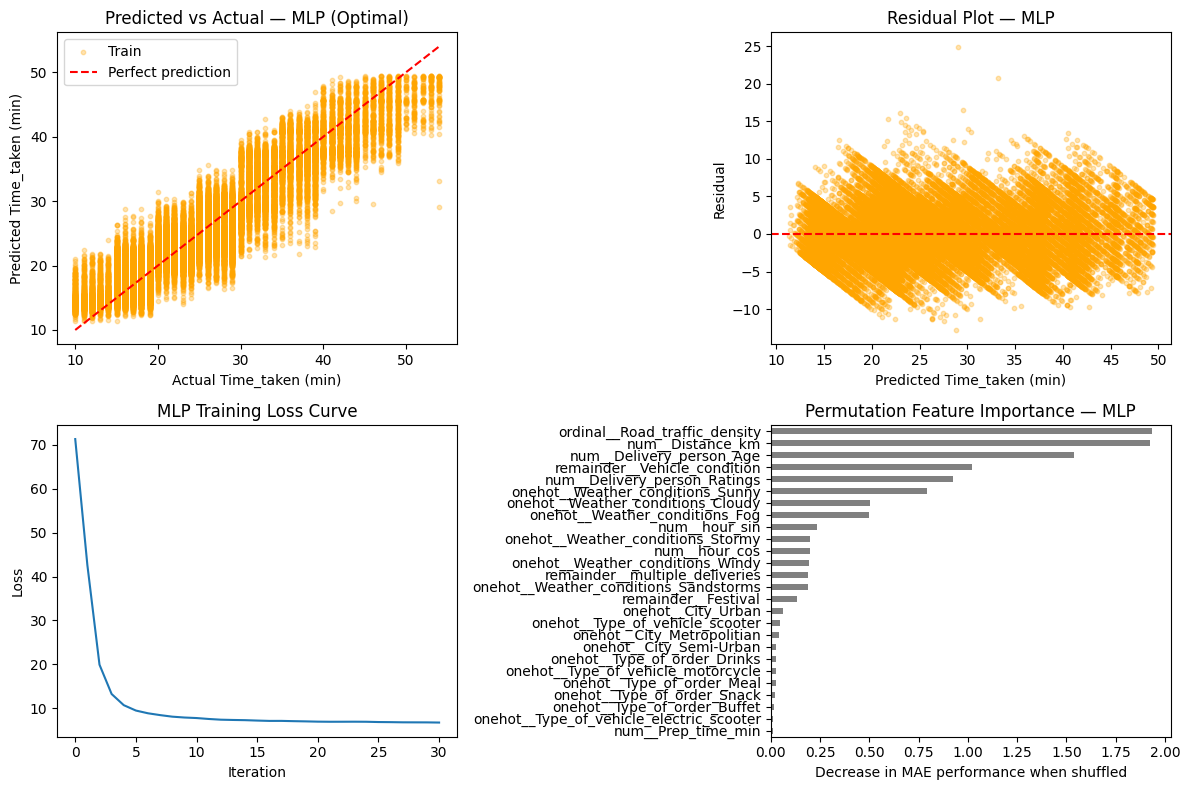

In [103]:
# Plots
fig, axes = plt.subplots(2,2, figsize=(12, 8))

# 1. Predicted vs. Actual
axes[0][0].scatter(y_train_clean, mlp_optimal.predict(X_train_encoded_norm), alpha=0.3, s=10, color='orange', label='Train')
lims = [y_train_clean.min(), y_train_clean.max()]
axes[0][0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0][0].set_xlabel('Actual Time_taken (min)')
axes[0][0].set_ylabel('Predicted Time_taken (min)')
axes[0][0].set_title('Predicted vs Actual — MLP (Optimal)')
axes[0][0].legend()


# 2. Residual plot
residuals = y_train_clean - mlp_optimal.predict(X_train_encoded_norm)
axes[0][1].scatter(mlp_optimal.predict(X_train_encoded_norm), residuals, alpha=0.3, s=10, color='orange')
axes[0][1].axhline(0, color='red', linestyle='--')
axes[0][1].set_xlabel('Predicted Time_taken (min)')
axes[0][1].set_ylabel('Residual')
axes[0][1].set_title('Residual Plot — MLP')


# 3. Training loss curve
print(f"Converged in {mlp_optimal.n_iter_} iterations")
print(f"Final loss: {mlp_optimal.loss_:.4f}")
axes[1][0].plot(mlp_optimal.loss_curve_)
axes[1][0].set_xlabel('Iteration')
axes[1][0].set_ylabel('Loss')
axes[1][0].set_title('MLP Training Loss Curve')

# 4. Permutation importance (instead of .coef_/.feature_importances_)
perm_result = permutation_importance(mlp_optimal, X_train_encoded_norm, y_train_clean, 
                                       n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
perm_importances = pd.Series(perm_result.importances_mean, index=feature_names).sort_values()

perm_importances.plot(kind='barh', ax=axes[1][1], color='gray')
axes[1][1].set_xlabel('Decrease in MAE performance when shuffled')
axes[1][1].set_title('Permutation Feature Importance — MLP')

plt.tight_layout()
plt.show()

In [104]:
# compare permutation feature imporances
perm_mae = permutation_importance(mlp_optimal, X_train_encoded_norm, y_train_clean, 
                                     n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
perm_rmse = permutation_importance(mlp_optimal, X_train_encoded_norm, y_train_clean, 
                                      n_repeats=10, random_state=42, scoring='neg_root_mean_squared_error')

comparison = pd.DataFrame({
    'MAE_importance': -perm_mae.importances_mean,
    'RMSE_importance': -perm_rmse.importances_mean,
}, index=feature_names).sort_values('MAE_importance', ascending=False)

comparison['MAE_rank'] = comparison['MAE_importance'].rank(ascending=False).astype(int)
comparison['RMSE_rank'] = comparison['RMSE_importance'].rank(ascending=False).astype(int)

comparison

,MAE_importance,RMSE_importance,MAE_rank,RMSE_rank
num__Prep_time_min,-0.012232,-0.014814,1,1
onehot__Type_of_vehicle_electric_scooter,-0.013794,-0.017144,2,2
onehot__Type_of_order_Buffet,-0.017768,-0.023962,3,3
onehot__Type_of_order_Snack,-0.022559,-0.032317,4,4
onehot__Type_of_order_Meal,-0.024595,-0.035617,5,6
onehot__Type_of_vehicle_motorcycle,-0.025414,-0.039413,6,7
onehot__Type_of_order_Drinks,-0.026539,-0.033509,7,5
onehot__City_Semi-Urban,-0.028178,-0.050634,8,8
onehot__City_Metropolitian,-0.041045,-0.053269,9,9
onehot__Type_of_vehicle_scooter,-0.044837,-0.075150,10,10


### 4. Stacking

In [105]:
# 1. Check which models are redundant
model_data = {
    'Linear Regression': (LinearRegression(), X_train_encoded_norm),
    'Ridge': (Ridge(alpha=ridge_cv.alpha_), X_train_encoded_norm),
    'Lasso': (Lasso(alpha=lasso_cv.alpha_), X_train_encoded_norm),
    'Random Forest': (RandomForestRegressor(random_state=42, **rf_search.best_params_), X_train_encoded_raw),
    'XGBoost': (XGBRegressor(random_state=42, **xgb_search.best_params_), X_train_encoded_raw),
    'LightGBM': (LGBMRegressor(random_state=42, **lgbm_random.best_params_), X_train_encoded_raw),
    'CatBoost': (CatBoostRegressor(random_state=42, verbose=0, **cat_search.best_params_), X_train_encoded_raw),
    'CatBoost_Native': (CatBoostNativeWrapper(cat_features=cat_features, random_state=42,
                                        verbose=0, **cat_native_search.best_params_), X_train_clean),
    'MLP': (MLPRegressor(random_state=42, max_iter=1000, early_stopping=True,
                          solver='adam', **mlp_search.best_params_), X_train_encoded_raw)
}

oof_preds = {}
for name, (model, X) in model_data.items():
    oof_preds[name] = cross_val_predict(model, X, y_train_clean, cv=kf, method='predict')

oof_df = pd.DataFrame(oof_preds)

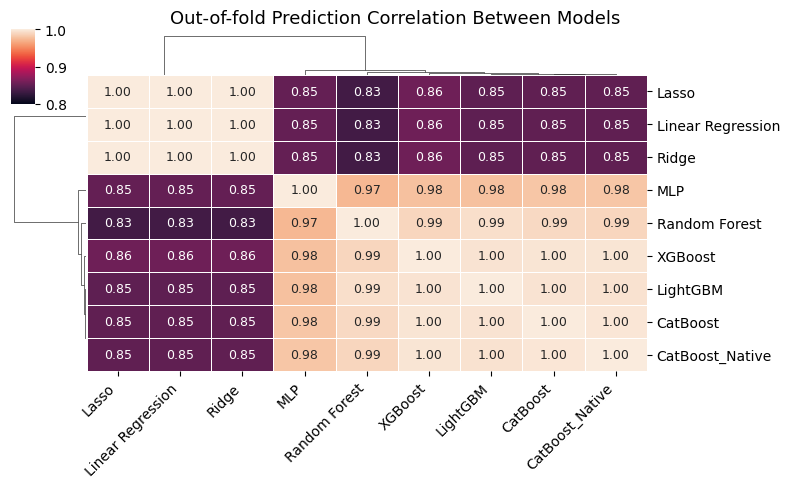

In [106]:
# Plot relationship between models
g = sns.clustermap(
    oof_df.corr(),
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    # cmap='Blues',              # light = low corr, dark = high corr (intuitive)
    vmin=0.8, vmax=1.0,
    linewidths=0.5,
    linecolor='white',
    figsize=(8, 5),
    dendrogram_ratio=(0.12, 0.12),   # slimmer dendrograms, more room for heatmap
    cbar_pos=(0.02, 0.83, 0.03, 0.15)#,  # move colorbar to top-left, out of the way
    # cbar_kws={'label': 'Correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=10)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')

g.fig.suptitle('Out-of-fold Prediction Correlation Between Models', y=1.02, fontsize=13)

plt.show()

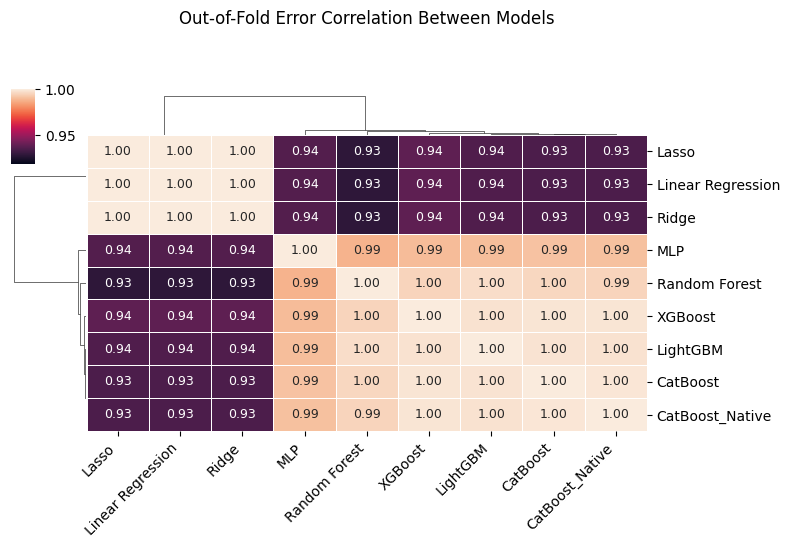

In [121]:
oof_errors = oof_df.copy()
for col in oof_errors.columns:
    oof_errors[col] = y_train_clean - oof_errors[col]

error_corr = oof_errors.corr()

g = sns.clustermap(
    error_corr,
    annot=True,
    fmt=".2f",
    cmap="rocket",          # or "magma" / "flare" — same family as image 1
    vmin=error_corr.values[~np.eye(len(error_corr), dtype=bool)].min() - 0.01,
    vmax=1.0,
    center=None,
    linewidths=0.5,
    linecolor="white",
    figsize=(8, 5),
    dendrogram_ratio=(0.12, 0.12),
    cbar_pos=(0.02, 0.83, 0.03, 0.15),
    annot_kws={"size": 9}
)

g.ax_heatmap.set_title("Out-of-Fold Error Correlation Between Models", pad=80)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.show()

In [122]:
# all model cv scores
all_results_cv = [
    reg_cv_score, ridge_cv_score, lasso_cv_score, 
    rf_optimal_cv_score, 
    xgb_optimal_cv_score, lgbm_optimal_cv_score, cat_optimal_cv_score, cat_native_optimal_cv_score,
    mlp_optimal_cv_score
]

summary_cols_cv = ['model_name',
                 'cv_train_MAE', 'cv_train_RMSE', 'cv_train_R2', 'cv_train_MAPE',
                 'cv_MAE', 'cv_RMSE', 'cv_R2', 'cv_MAPE']

all_results_cv = pd.DataFrame(all_results_cv)[summary_cols_cv]

formatters_cv = {
    'cv_train_MAE': '{:.3f}'.format, 'cv_MAE': '{:.3f}'.format,
    'cv_train_RMSE': '{:.3f}'.format, 'cv_RMSE': '{:.3f}'.format,
    'cv_train_R2': '{:.2%}'.format, 'cv_R2': '{:.2%}'.format,
    'cv_train_MAPE': '{:.2%}'.format, 'cv_MAPE': '{:.2%}'.format,
}

print(all_results_cv.to_string(index=False, formatters=formatters_cv))

           model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
     LinearRegression        4.709         5.914      59.88%        20.61%  4.712   5.919 59.80%  20.62%
                Ridge        4.709         5.914      59.88%        20.61%  4.712   5.919 59.80%  20.62%
                Lasso        4.709         5.914      59.88%        20.61%  4.712   5.919 59.80%  20.63%
RandomForestRegressor        2.570         3.197      88.27%        10.96%  3.042   3.778 83.62%  12.99%
         XGBRegressor        2.842         3.534      85.67%        12.25%  3.034   3.769 83.70%  13.01%
        LGBMRegressor        2.878         3.545      85.59%        12.41%  2.989   3.697 84.32%  12.83%
    CatBoostRegressor        2.739         3.396      86.77%        11.78%  2.989   3.702 84.27%  12.79%
CatBoostNativeWrapper        2.882         3.575      85.34%        12.36%  2.999   3.719 84.13%  12.83%
         MLPRegressor        2.896         3.583      8

In [131]:
# 2. Build stack model (Lasso + LightGBM)

# create input_X for the stack model
oof_stack_df = oof_df[['Lasso', 'LightGBM']]

# fit the stack model
meta_model = RidgeCV()
meta_model.fit(oof_stack_df, y_train_clean)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [132]:
# Stack model coefficients
print("Meta-model weights:")
for name, coef in zip(oof_stack_df.columns, meta_model.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"  intercept: {meta_model.intercept_:.4f}")

Meta-model weights:
  Lasso: -0.0287
  LightGBM: 1.0432
  intercept: -0.3802


Stack model:

stack_prediction = -0.0287 × Lasso_pred + 1.0433 × LightGBM_pred − 0.3802

# Part 3: Model Evaluation

### 1. All CV Results 

In [133]:
# All model cv results
print(all_results_cv.to_string(index=False, formatters=formatters_cv))

           model_name cv_train_MAE cv_train_RMSE cv_train_R2 cv_train_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
     LinearRegression        4.709         5.914      59.88%        20.61%  4.712   5.919 59.80%  20.62%
                Ridge        4.709         5.914      59.88%        20.61%  4.712   5.919 59.80%  20.62%
                Lasso        4.709         5.914      59.88%        20.61%  4.712   5.919 59.80%  20.63%
RandomForestRegressor        2.570         3.197      88.27%        10.96%  3.042   3.778 83.62%  12.99%
         XGBRegressor        2.842         3.534      85.67%        12.25%  3.034   3.769 83.70%  13.01%
        LGBMRegressor        2.878         3.545      85.59%        12.41%  2.989   3.697 84.32%  12.83%
    CatBoostRegressor        2.739         3.396      86.77%        11.78%  2.989   3.702 84.27%  12.79%
CatBoostNativeWrapper        2.882         3.575      85.34%        12.36%  2.999   3.719 84.13%  12.83%
         MLPRegressor        2.896         3.583      8

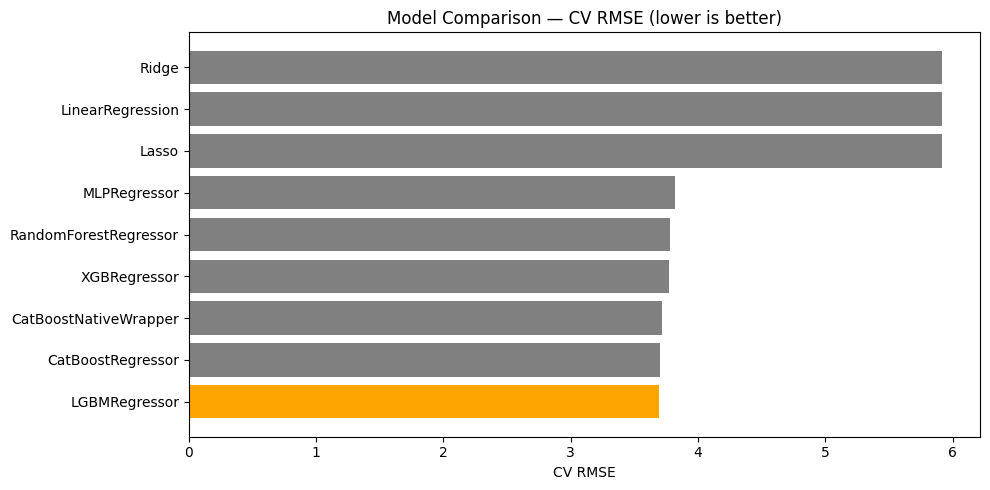

In [134]:
comparison_df = pd.DataFrame(all_results_cv)[['model_name', 'cv_RMSE']].sort_values('cv_RMSE')
optimal_model_name = 'LGBMRegressor'

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gray' if m != optimal_model_name else 'orange' for m in comparison_df['model_name']]
ax.barh(comparison_df['model_name'], comparison_df['cv_RMSE'], color=colors)
ax.set_xlabel('CV RMSE')
ax.set_title('Model Comparison — CV RMSE (lower is better)')
plt.tight_layout()
plt.show()


### 2. Evaluate on the test set

In [135]:
# function to print the model result (out-of-sample: test set)
def print_result(model, in_X, in_y, out_X, out_y, verbose=True):
    # in-sample
    in_pred = model.predict(in_X)
    in_mae = mean_absolute_error(in_y, in_pred)
    in_rmse = root_mean_squared_error(in_y, in_pred)
    in_r2 = r2_score(in_y, in_pred)
    in_mape = mean_absolute_percentage_error(in_y, in_pred)

    # out-of-sample
    out_pred = model.predict(out_X)
    out_mae = mean_absolute_error(out_y, out_pred)
    out_rmse = root_mean_squared_error(out_y, out_pred)
    out_r2 = r2_score(out_y, out_pred)
    out_mape = mean_absolute_percentage_error(out_y, out_pred)

    # number of vars
    num_vars = len(model.coef_[model.coef_ != 0]) if hasattr(model, 'coef_') else in_X.shape[1]

    result = {
        'model_name': type(model).__name__,
        'num_vars': num_vars,
        'in_MAE': in_mae,
        'in_RMSE': in_rmse,
        'in_R2': in_r2,
        'in_MAPE': in_mape,
        'out_MAE': out_mae,
        'out_RMSE': out_rmse,
        'out_R2': out_r2,
        'out_MAPE': out_mape,
        'in_pred': in_pred,
        'out_pred': out_pred
    }

    if verbose:
        summary_cols = ['model_name', 'num_vars',
                        'in_MAE', 'in_RMSE', 'in_R2', 'in_MAPE',
                        'out_MAE', 'out_RMSE', 'out_R2', 'out_MAPE']

        summary_df = pd.DataFrame([{k: result[k] for k in summary_cols}])

        formatters = {
        'in_MAE': '{:.3f}'.format, 'out_MAE': '{:.3f}'.format,
        'in_RMSE': '{:.3f}'.format, 'out_RMSE': '{:.3f}'.format,
        'in_R2': '{:.2%}'.format, 'out_R2': '{:.2%}'.format,
        'in_MAPE': '{:.2%}'.format, 'out_MAPE': '{:.2%}'.format,
    }
        print(summary_df.to_string(index=False, formatters=formatters))

    return result

#### LightGBM

In [136]:
lgbm_final_result = print_result(lgbm_optimal, X_train_encoded_raw, y_train_clean, X_test_encoded_raw, y_test_clean)

   model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
LGBMRegressor        26  2.895   3.567 85.40%  12.47%   2.991    3.698 84.32%   12.84%


#### Stack: Lasso + LightGBM

In [137]:
# function for prediction using the stack model
def stack_predict(X_norm, X_raw):
    meta_input = pd.DataFrame({
        'Lasso': lasso_final.predict(X_norm),
        'LightGBM': lgbm_optimal.predict(X_raw)
    })
    return meta_model.predict(meta_input)

# prection
stack_test_preds = stack_predict(X_test_encoded_norm, X_test_encoded_raw)

# out-of-sample errors
mae = mean_absolute_error(y_test_clean, stack_test_preds)
rmse = root_mean_squared_error(y_test_clean, stack_test_preds)
r2 = r2_score(y_test_clean, stack_test_preds)
mape = mean_absolute_percentage_error(y_test_clean, stack_test_preds)

print(f"Stack — MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2*100:.2f}%, MAPE: {mape:.2%}")

Stack — MAE: 2.987, RMSE: 3.690, R2: 84.39%, MAPE: 12.76%


#### CatBoost Native

In [138]:
cat_native_final_result = print_result(cat_native_optimal, X_train_clean, y_train_clean, X_test_clean, y_test_clean)

       model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
CatBoostRegressor        14  2.879   3.559 85.47%  12.33%   2.954    3.670 84.55%   12.61%


#### All Models

In [139]:
# map each final model to its train/test feature sets
final_models = {
    'LinearRegression': (reg_final, X_train_encoded_norm, X_test_encoded_norm),
    'Ridge': (ridge_final, X_train_encoded_norm, X_test_encoded_norm),
    'Lasso': (lasso_final, X_train_encoded_norm, X_test_encoded_norm),
    'RandomForest': (rf_optimal, X_train_encoded_raw, X_test_encoded_raw),
    'XGBoost': (xgb_optimal, X_train_encoded_raw, X_test_encoded_raw),
    'LightGBM': (lgbm_optimal, X_train_encoded_raw, X_test_encoded_raw),
    'CatBoost': (cat_optimal, X_train_encoded_raw, X_test_encoded_raw),
    'CatBoost_Native': (cat_native_optimal, X_train_clean, X_test_clean),
    'MLP': (mlp_optimal, X_train_encoded_norm, X_test_encoded_norm),
}

all_test_results = {}
for name, (model, X_train_, X_test_) in final_models.items():
    all_test_results[name] = print_result(model, X_train_, y_train_clean, X_test_, y_test_clean, verbose=False)

# format
summary_cols = ['model_name', 'num_vars',
                 'in_MAE', 'in_RMSE', 'in_R2', 'in_MAPE',
                 'out_MAE', 'out_RMSE', 'out_R2', 'out_MAPE']

summary_df = pd.DataFrame([
    {k: all_test_results[name][k] for k in summary_cols} for name in all_test_results
])
summary_df.index = all_test_results.keys()  # use your dict keys as row labels

formatters = {
    'in_MAE': '{:.3f}'.format, 'out_MAE': '{:.3f}'.format,
    'in_RMSE': '{:.3f}'.format, 'out_RMSE': '{:.3f}'.format,
    'in_R2': '{:.2%}'.format, 'out_R2': '{:.2%}'.format,
    'in_MAPE': '{:.2%}'.format, 'out_MAPE': '{:.2%}'.format,
}

print(summary_df.to_string(formatters=formatters))

                             model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
LinearRegression       LinearRegression        26  4.709   5.914 59.88%  20.61%   4.782    5.973 59.08%   20.82%
Ridge                             Ridge        26  4.709   5.914 59.88%  20.61%   4.782    5.973 59.08%   20.82%
Lasso                             Lasso        24  4.709   5.914 59.87%  20.61%   4.783    5.974 59.08%   20.83%
RandomForest      RandomForestRegressor        26  2.557   3.177 88.42%  10.91%   3.034    3.762 83.77%   12.93%
XGBoost                    XGBRegressor        26  2.871   3.571 85.37%  12.37%   3.031    3.782 83.60%   12.98%
LightGBM                  LGBMRegressor        26  2.895   3.567 85.40%  12.47%   2.991    3.698 84.32%   12.84%
CatBoost              CatBoostRegressor        26  2.778   3.441 86.41%  11.95%   2.969    3.690 84.38%   12.71%
CatBoost_Native       CatBoostRegressor        14  2.879   3.559 85.47%  12.33%   2.954    3.670

# Part 4. Model Interpretation

### 1. Final Model: CatBoost Native Residual Plots

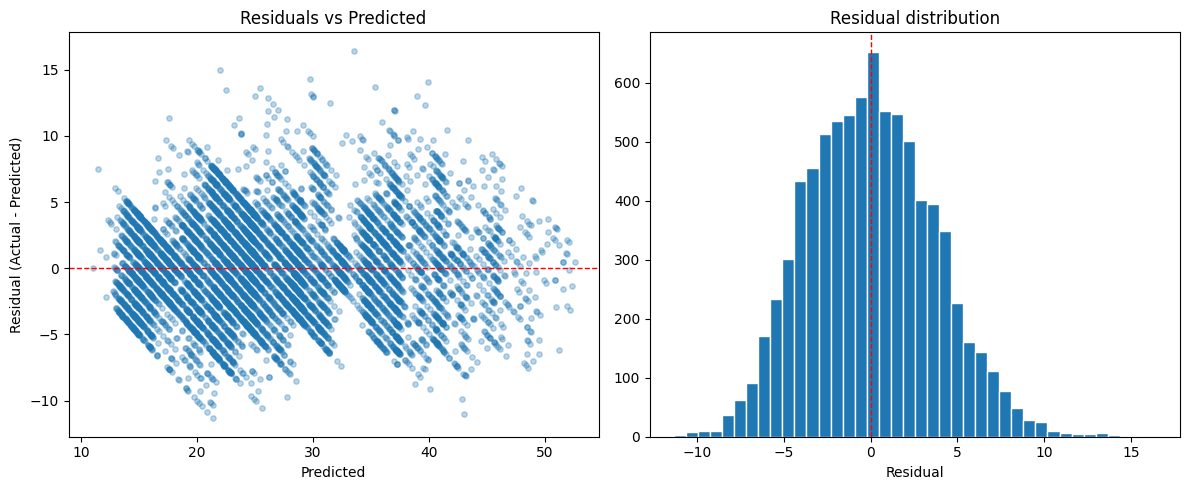

In [140]:
residuals = y_test_clean - cat_native_final_result['out_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs predicted — check for patterns (heteroscedasticity, bias)
axes[0].scatter(cat_native_final_result['out_pred'], residuals, alpha=0.3, s=15)
axes[0].axhline(0, color='r', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted')

# Residual distribution — check for normality/skew
axes[1].hist(residuals, bins=40, edgecolor='white')
axes[1].axvline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.show()


### 2. Feature Importance / SHAP analysis

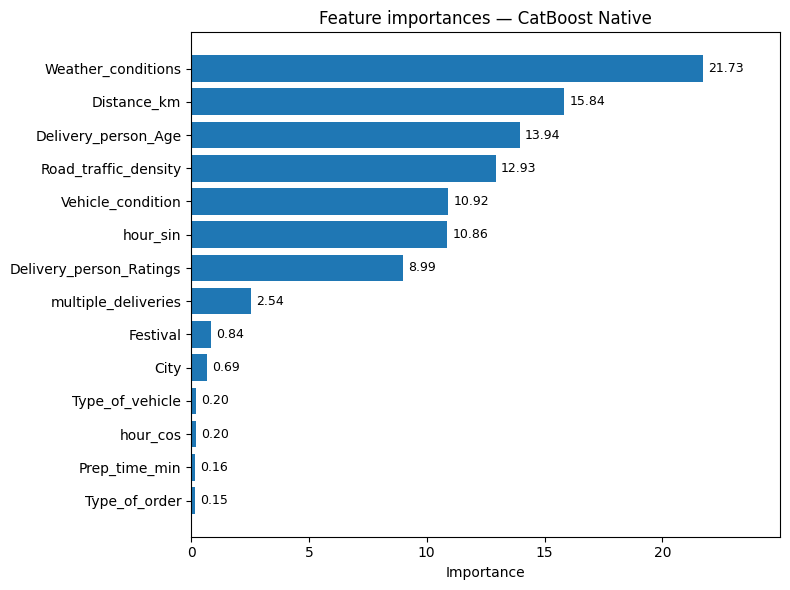

In [141]:
importances = cat_native_optimal.get_feature_importance()
feat_imp_df = pd.DataFrame({
    'feature': X_train_clean.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

# print(feat_imp_df.to_string(index=False))

feat_imp_sorted = feat_imp_df[::-1]  # reverse so largest is on top in barh

plt.figure(figsize=(8, 6))
bars = plt.barh(feat_imp_sorted['feature'], feat_imp_sorted['importance'])
plt.xlabel('Importance')
plt.title('Feature importances — CatBoost Native')

# add value labels at the end of each bar
max_val = feat_imp_sorted['importance'].max()
for bar, val in zip(bars, feat_imp_sorted['importance']):
    plt.text(
        bar.get_width() + max_val * 0.01,   # small offset past bar end
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha='left', fontsize=9
    )

# give a bit of extra room so labels aren't clipped
plt.xlim(0, max_val * 1.15)

plt.tight_layout()
plt.show()

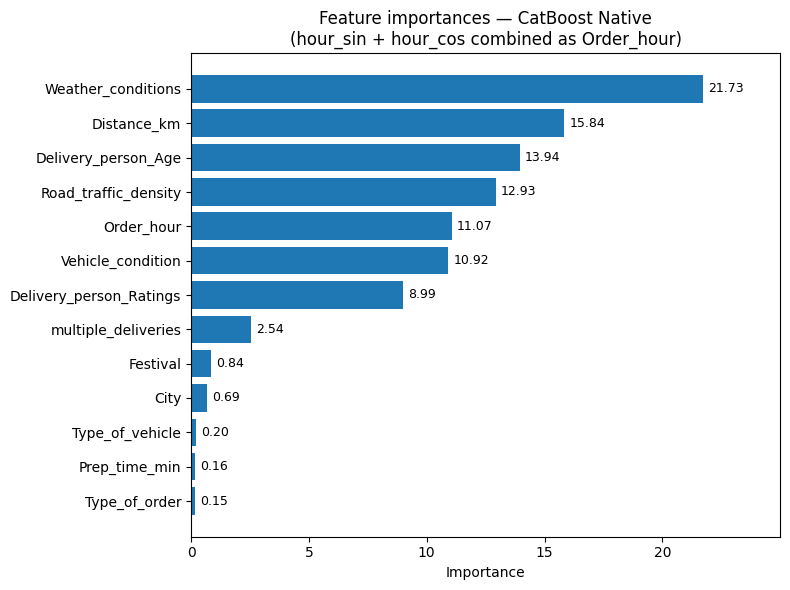

In [143]:
# --- combine hour_sin + hour_cos into a single "Order_hour" bar for reporting ---
hour_mask = feat_imp_df['feature'].isin(['hour_sin', 'hour_cos'])
hour_importance = feat_imp_df.loc[hour_mask, 'importance'].sum()

feat_imp_display = feat_imp_df.loc[~hour_mask].copy()
feat_imp_display = pd.concat([
    feat_imp_display,
    pd.DataFrame({'feature': ['Order_hour'], 'importance': [hour_importance]})
], ignore_index=True)

feat_imp_display = feat_imp_display.sort_values('importance', ascending=False)

# print(feat_imp_display.to_string(index=False))

feat_imp_sorted = feat_imp_display[::-1]  # reverse so largest is on top in barh

plt.figure(figsize=(8, 6))
bars = plt.barh(feat_imp_sorted['feature'], feat_imp_sorted['importance'])
plt.xlabel('Importance')
plt.title('Feature importances — CatBoost Native\n(hour_sin + hour_cos combined as Order_hour)')

# add value labels at the end of each bar
max_val = feat_imp_sorted['importance'].max()
for bar, val in zip(bars, feat_imp_sorted['importance']):
    plt.text(
        bar.get_width() + max_val * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha='left', fontsize=9
    )

# give a bit of extra room so labels aren't clipped
plt.xlim(0, max_val * 1.15)

plt.tight_layout()
plt.show()

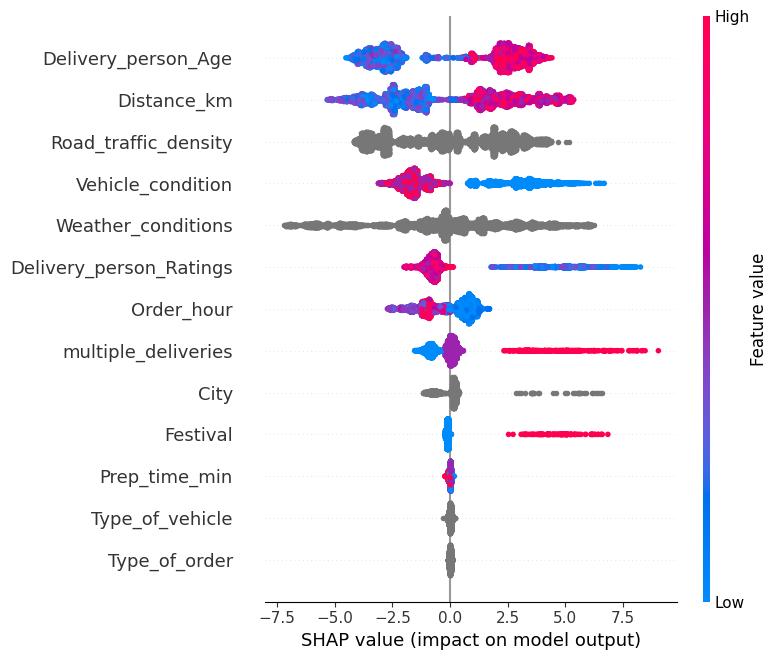

In [144]:
# SHAP analysis
explainer = shap.TreeExplainer(cat_native_optimal)
shap_values = explainer.shap_values(X_test_clean)

# --- combine hour_sin + hour_cos SHAP values into a single Order_hour column ---
feature_names = list(X_test_clean.columns)
sin_idx = feature_names.index('hour_sin')
cos_idx = feature_names.index('hour_cos')

# sum the two columns of shap_values (rows = samples, cols = features)
combined_hour_shap = shap_values[:, sin_idx] + shap_values[:, cos_idx]

# build a new shap_values array with the two hour columns replaced by one
keep_mask = np.array([i not in (sin_idx, cos_idx) for i in range(len(feature_names))])
shap_values_combined = np.column_stack([shap_values[:, keep_mask], combined_hour_shap])

# matching feature names + a matching X (for coloring dots by feature value)
feature_names_combined = [f for i, f in enumerate(feature_names) if keep_mask[i]] + ['Order_hour']

X_test_combined = X_test_clean.loc[:, keep_mask].copy()
X_test_combined['Order_hour'] = X_test_clean['hour_sin']  # placeholder for coloring — see note below

shap.summary_plot(shap_values_combined, X_test_combined, feature_names=feature_names_combined)

### 3. Error Analysis by Segment

In [146]:
# 1. error
error_df = X_test_clean.copy()

# 2.Reconstruct Order_hour from hour_sin/hour_cos (if raw column wasn't kept)
angle = np.arctan2(X_test_clean['hour_sin'], X_test_clean['hour_cos'])  # radians, range -π to π
hour_reconstructed = (angle / (2 * np.pi)) * 24
hour_reconstructed = np.round(hour_reconstructed) % 24  # wrap negatives back into 0-23

error_df['Order_hour'] = hour_reconstructed.values

# 3. prediction
error_df['actual'] = y_test_clean.values
error_df['predicted'] = cat_native_final_result['out_pred']
error_df['abs_error'] = np.abs(error_df['actual'] - error_df['predicted'])

overall_mean = error_df['abs_error'].mean()
n_total = len(error_df)

# 4. distance buckets
error_df["distance_bucket"] = pd.cut(
    error_df["Distance_km"],
    bins=[0, 2, 5, 10, np.inf],
    labels=["0-2 km", "2-5 km", "5-10 km", "10+ km"]
)

# aggregate MAE by segment
mae_by_distance = error_df.groupby("distance_bucket")["abs_error"].mean()
print(mae_by_distance)

# 5. Peak vs off-peak
error_df['time_period'] = np.where(
    error_df['Order_hour'].isin([11,12,13,18,19,20]),  # adjust peak hours to your data
    'Peak', 'Off-peak'
)

mae_by_time = error_df.groupby("time_period")["abs_error"].mean()
print(mae_by_time)

# 6. feature lists
numeric_features = ['Delivery_person_Age', 'Delivery_person_Ratings']
discrete_features = ['Vehicle_condition', 'multiple_deliveries', 'Prep_time_min', 'Festival']
bin_features = ['distance_bucket', 'time_period']

all_features = cat_features + numeric_features + bin_features + discrete_features

distance_bucket
0-2 km     2.551725
2-5 km     2.746637
5-10 km    2.779846
10+ km     3.205830
Name: abs_error, dtype: float64
time_period
Off-peak    2.829187
Peak        3.144394
Name: abs_error, dtype: float64


In [147]:
BAR_COLOR = 'steelblue'
MEAN_COLOR = 'darkorange'
LINE_COLOR = 'firebrick'

# plot helper functions
def plot_categorical(ax, col):
    grouped = error_df.groupby(col, observed=True)['abs_error']
    means = grouped.mean().sort_values()
    counts = grouped.count().loc[means.index]
    pcts = counts / n_total * 100

    bars = ax.barh(means.index.astype(str), means.values, color=BAR_COLOR)
    for bar, m, n, pct in zip(bars, means.values, counts.values, pcts.values):
        # value label (bold, right at bar end)
        ax.text(bar.get_width() + means.max() * 0.02,
                 bar.get_y() + bar.get_height() / 2,
                 f'{m:.2f}', va='center', fontsize=8, fontweight='bold', color='black')
        # n= label, pushed further right
        ax.text(bar.get_width() + means.max() * 0.14,
                 bar.get_y() + bar.get_height() / 2,
                 f'n={n} ({pct:.0f}%)', va='center', fontsize=7, color='gray')

    ax.axvline(overall_mean, color=MEAN_COLOR, linestyle='--', linewidth=1)
    ax.set_xlim(means.min() * 0.85, means.max() * 1.35)  # widened for extra text
    ax.set_title(f'MAE by {col}', fontsize=10)
    ax.set_xlabel('Mean absolute error', fontsize=8)


def plot_discrete(ax, col):
    grouped = error_df.groupby(col, observed=True)['abs_error']
    means = grouped.mean().sort_index()
    counts = grouped.count().sort_index()
    pcts = counts / n_total * 100
    max_n = counts.max()

    x = range(len(means))
    for xi, m, n, pct in zip(x, means.values, counts.values, pcts.values):
        alpha = 0.35 + 0.65 * (n / max_n)
        ax.bar(xi, m, color=BAR_COLOR, alpha=alpha)
        # value label just above bar
        ax.text(xi, m + means.max() * 0.04, f'{m:.2f}',
                 ha='center', fontsize=8, fontweight='bold', color='black')
        # n= label above the value label
        ax.text(xi, m + means.max() * 0.14, f'n={n} ({pct:.0f}%)',
                 ha='center', fontsize=7, color='gray')

    ax.set_xticks(x)
    ax.set_xticklabels(means.index.astype(str), rotation=0, fontsize=8)
    ax.axhline(overall_mean, color=MEAN_COLOR, linestyle='--', linewidth=1)
    ax.set_ylim(0, means.max() * 1.45)  # extra headroom for two lines of text
    ax.set_title(f'MAE by {col}', fontsize=10)
    ax.set_ylabel('Mean absolute error', fontsize=8)


def plot_numeric_binned(ax, col, q=8):
    binned = pd.qcut(error_df[col], q=q, duplicates='drop')
    labels = [f'{iv.left:.1f}\u2013{iv.right:.1f}' for iv in binned.cat.categories]
    binned = binned.cat.rename_categories(labels)

    grouped = error_df.groupby(binned, observed=True)['abs_error']
    means = grouped.mean()
    counts = grouped.count()
    max_n = counts.max()

    x = range(len(means))
    for xi, m, n in zip(x, means.values, counts.values):
        alpha = 0.35 + 0.65 * (n / max_n)
        ax.bar(xi, m, color=BAR_COLOR, alpha=alpha)
        # value label above each bar
        ax.text(xi, m + means.max() * 0.03, f'{m:.2f}',
                 ha='center', fontsize=7, fontweight='bold', color='black')

    ax.set_xticks(x)
    ax.set_xticklabels(means.index.astype(str), rotation=45, ha='right', fontsize=7)
    ax.axhline(overall_mean, color=MEAN_COLOR, linestyle='--', linewidth=1)
    ax.set_ylim(0, means.max() * 1.3)
    ax.set_title(f'MAE by {col}', fontsize=10)
    ax.set_ylabel('Mean absolute error', fontsize=8)

    # distribution/sample-count line on secondary axis
    ax2 = ax.twinx()
    ax2.plot(x, counts.values, color=LINE_COLOR, marker='o', markersize=4, linewidth=1.5)
    ax2.set_ylabel('Sample count', color=LINE_COLOR, fontsize=8)
    ax2.tick_params(axis='y', labelcolor=LINE_COLOR, labelsize=7)
    ax2.set_ylim(0, counts.max() * 1.2)


def plot_binned_category(ax, col, label=None):
    grouped = error_df.groupby(col, observed=True)['abs_error']
    means = grouped.mean()   # respects categorical order: 0-2, 2-5, 5-10, 10+
    counts = grouped.count()
    pcts = counts / n_total * 100
    max_n = counts.max()

    x = range(len(means))
    for xi, m, n, pct in zip(x, means.values, counts.values, pcts.values):
        alpha = 0.35 + 0.65 * (n / max_n)
        ax.bar(xi, m, color=BAR_COLOR, alpha=alpha)
        # value label just above bar
        ax.text(xi, m + means.max() * 0.04, f'{m:.2f}',
                 ha='center', fontsize=8, fontweight='bold', color='black')
        # n= label above the value label
        ax.text(xi, m + means.max() * 0.14, f'n={n} ({pct:.0f}%)',
                 ha='center', fontsize=7, color='gray')

    ax.set_xticks(x)
    ax.set_xticklabels(means.index.astype(str), rotation=0, fontsize=8)
    ax.axhline(overall_mean, color=MEAN_COLOR, linestyle='--', linewidth=1)
    ax.set_ylim(0, means.max() * 1.45)
    ax.set_title(f'MAE by {label or col}', fontsize=10)
    ax.set_ylabel('Mean absolute error', fontsize=8)

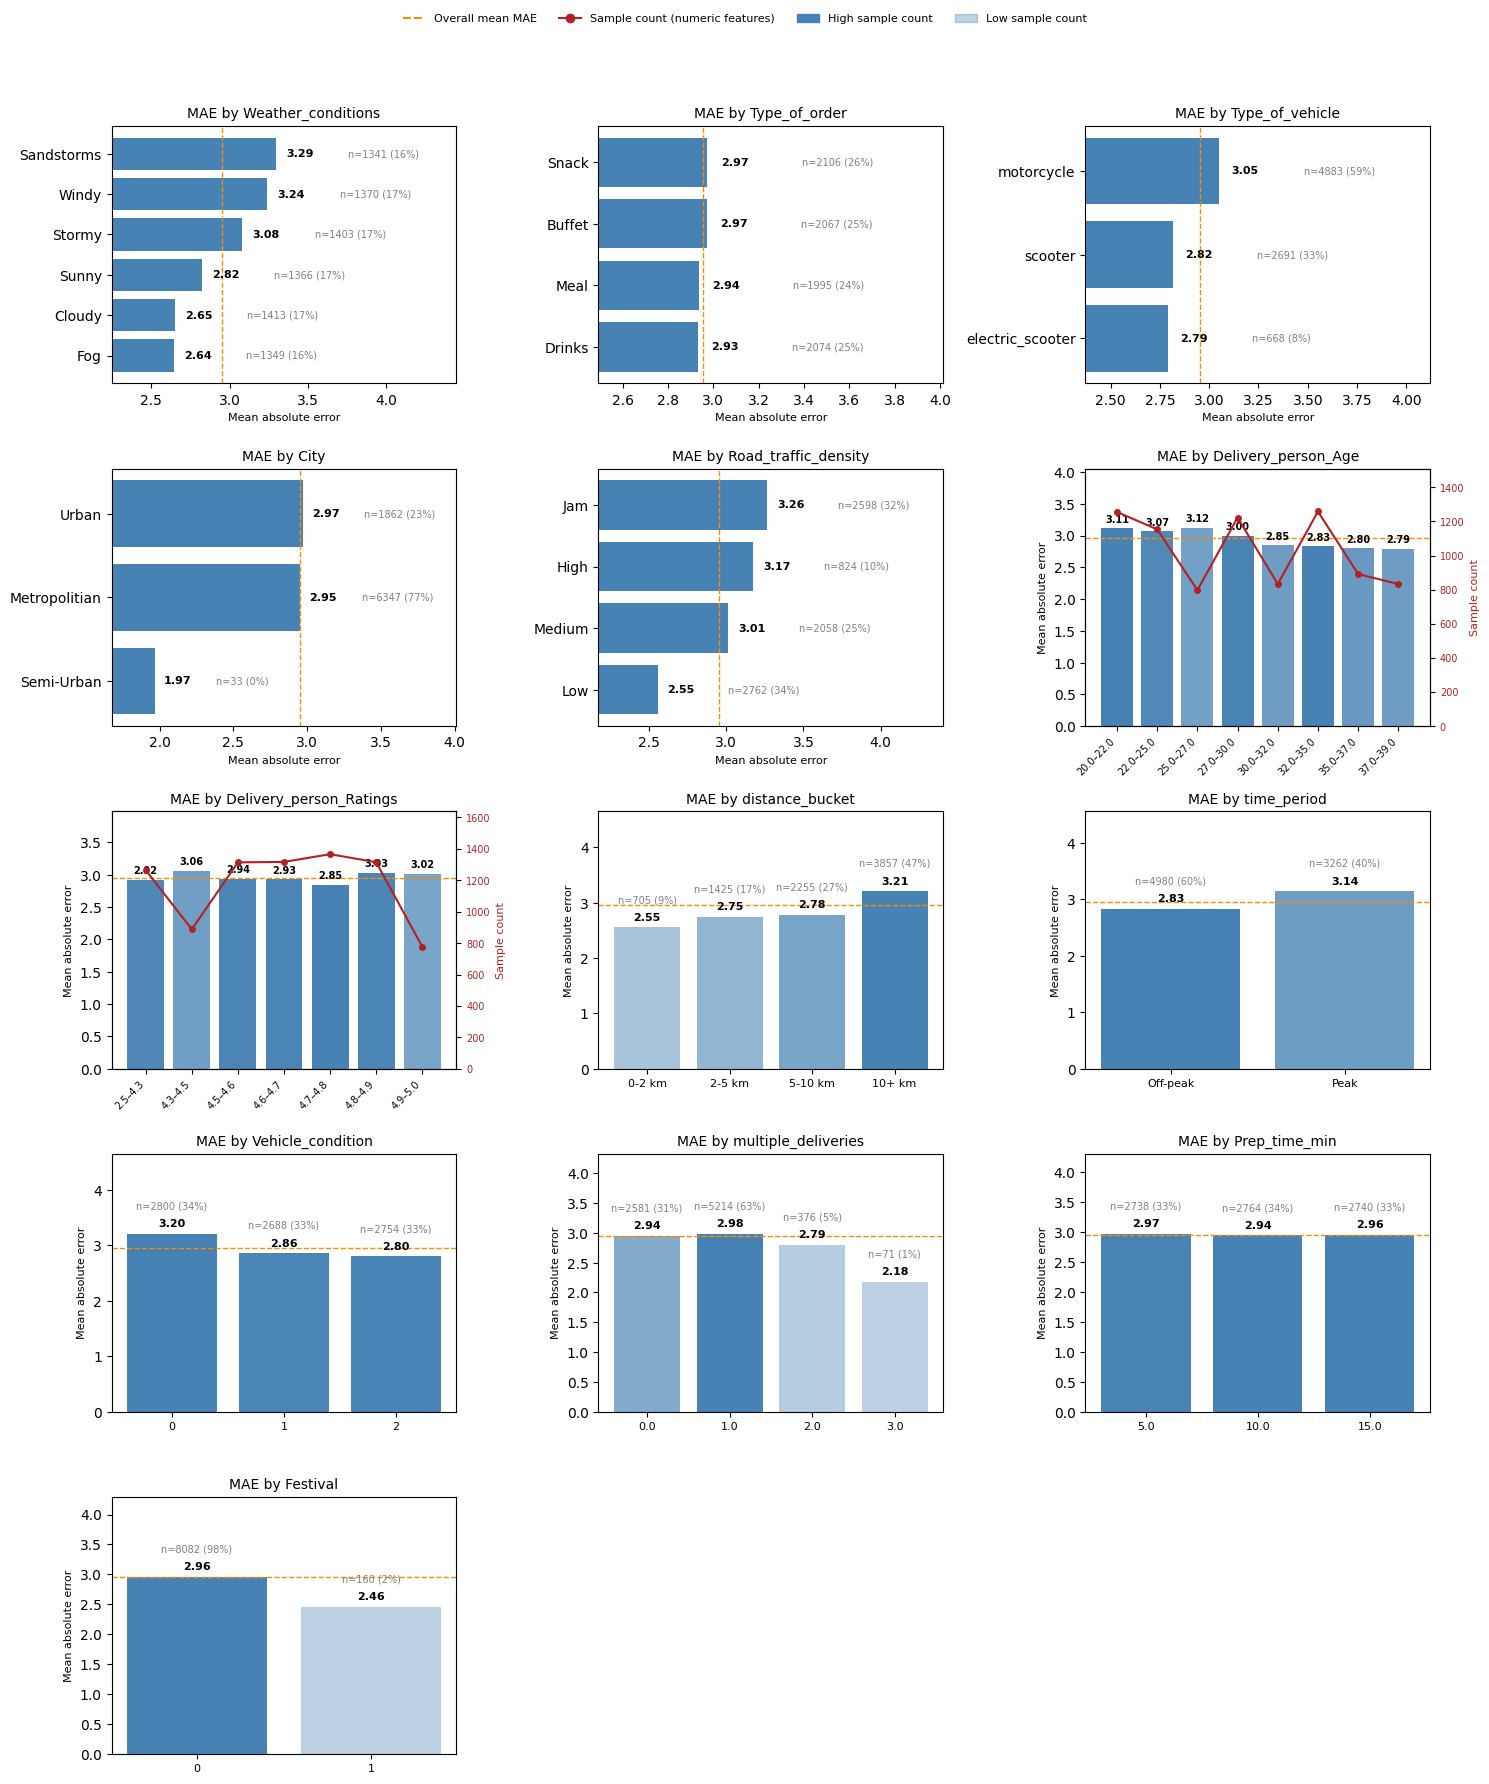

In [149]:
# plot
n_cols = 3
n_rows = -(-len(all_features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(all_features):
    if col in bin_features:
        plot_binned_category(axes[i], col)
    elif col in cat_features:
        plot_categorical(axes[i], col)
    elif col in discrete_features:
        plot_discrete(axes[i], col)
    else:
        plot_numeric_binned(axes[i], col)

for j in range(len(all_features), len(axes)):
    axes[j].set_visible(False)


# shared legend
handles = [
    plt.Line2D([0], [0], color=MEAN_COLOR, linestyle='--', label='Overall mean MAE'),
    plt.Line2D([0], [0], color=LINE_COLOR, marker='o', linewidth=1.5, label='Sample count (numeric features)'),
    plt.Rectangle((0, 0), 1, 1, color=BAR_COLOR, alpha=1.0, label='High sample count'),
    plt.Rectangle((0, 0), 1, 1, color=BAR_COLOR, alpha=0.35, label='Low sample count'),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=4, fontsize=8, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 4. Quantile regression

In [150]:
# reuse the exact tuned hyperparameters from your point model search
best_params = cat_native_search.best_params_

quantiles = {
    'lower': 0.1,
    'median': 0.5,
    'upper': 0.9
}

quantile_models = {}

for name, q in quantiles.items():
    model = CatBoostRegressor(
        loss_function=f'Quantile:alpha={q}',
        cat_features=cat_features,
        random_state=42,
        verbose=0,
        **best_params
    )
    model.fit(X_train_clean, y_train_clean)
    quantile_models[name] = model

# predict on test set
q_preds = {
    name: model.predict(X_test_clean) for name, model in quantile_models.items()
}

In [151]:
# Does the range actually mean what it claims?
# coverage: what % of true values fall inside [lower, upper]?
coverage = ((y_test_clean >= q_preds['lower']) & (y_test_clean <= q_preds['upper'])).mean()
print(f"Coverage (target ~80%): {coverage:.2%}")

# pinball loss per quantile — lower is better, standard metric for quantile models
for name, q in quantiles.items():
    loss = mean_pinball_loss(y_test_clean, q_preds[name], alpha=q)
    print(f"{name} (q={q}) pinball loss: {loss:.3f}")

# sanity check: median quantile prediction should track closely with your point model
median_vs_point_mae = np.mean(np.abs(q_preds['median'] - cat_native_final_result['out_pred']))
print(f"Median quantile pred vs point model MAE: {median_vs_point_mae:.3f}")

Coverage (target ~80%): 77.43%
lower (q=0.1) pinball loss: 0.550
median (q=0.5) pinball loss: 1.481
upper (q=0.9) pinball loss: 0.616
Median quantile pred vs point model MAE: 0.454


In [152]:
# Check that the range is actually adaptive, not just a shifted constant
results_df = X_test_clean.copy()
results_df['actual'] = y_test_clean.values
results_df['lower'] = q_preds['lower']
results_df['median'] = q_preds['median']
results_df['upper'] = q_preds['upper']
results_df['interval_width'] = results_df['upper'] - results_df['lower']

print(results_df.groupby('Weather_conditions')['interval_width'].mean().sort_values(ascending=False))
print(results_df.groupby('Road_traffic_density')['interval_width'].mean().sort_values(ascending=False))

Weather_conditions
Windy         10.170944
Sandstorms    10.052237
Stormy        10.045756
Fog            8.792523
Sunny          8.728097
Cloudy         8.578432
Name: interval_width, dtype: float64
Road_traffic_density
Jam       10.525087
Medium     9.817737
High       9.672442
Low        7.926969
Name: interval_width, dtype: float64


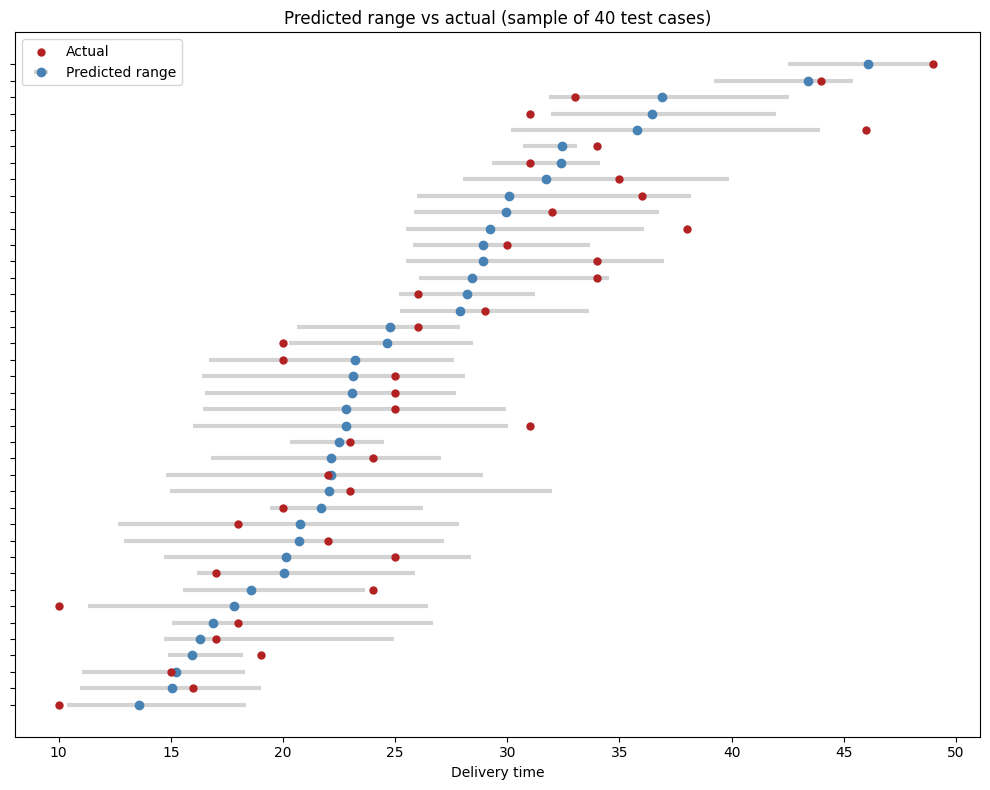

In [153]:
# Visualization
sample = results_df.sample(40, random_state=42).sort_values('median').reset_index()

plt.figure(figsize=(10, 8))
plt.errorbar(
    sample['median'], range(len(sample)),
    xerr=[sample['median'] - sample['lower'], sample['upper'] - sample['median']],
    fmt='o', color='steelblue', ecolor='lightgray', elinewidth=3, capsize=0, label='Predicted range'
)
plt.scatter(sample['actual'], range(len(sample)), color='firebrick', zorder=5, label='Actual', s=25)
plt.yticks(range(len(sample)), [])
plt.xlabel('Delivery time')
plt.legend()
plt.title('Predicted range vs actual (sample of 40 test cases)')
plt.tight_layout()
plt.show()

# Part 5. Save the final model

In [154]:
import joblib
joblib.dump(cat_native_optimal, 'catboost_native_final_model.pkl')

['catboost_native_final_model.pkl']